# Trabalho 3 - Fundamentos de Inteligência Artificial

**Integrantes**: Anna Luisa Antony Afonso, Elaine de Castro Freire, Giovanna Bembom da Silva Bandeira, Luiggy Augusto Lima Alves, Manuela Figueira Batista, Maria Flach da Costa, Mariana Ramos André Simões e Raíssa Clara Teixeira Brasil.

**Objetivo**: Construção de um agente neuro-simbólico capaz de entender relações espaciais. Diferente do Deep Learning padrão, que apenas mapeia Input → Output, usa-se Logic Tensor Networks (LTN) para ensinar à rede regras lógicas sobre como objetos se relacionam entre si em um espaço 2D.

# NeSy, LTN e Dataset CLEVR -



1.   **NeSy:**
O **Neuro-Symbolic Learning (NeSy)** é um paradigma da Inteligência Artificial que integra **modelos neurais**, responsáveis pelo aprendizado a partir de dados, com **métodos simbólicos**, baseados em lógica formal e representação explícita de conhecimento. Essa integração visa combinar capacidade de generalização com **interpretabilidade** e **raciocínio estruturado**.


2.   **LTN:**
As **Logic Tensor Networks (LTN)** são um framework neuro-simbólico que integra **lógica de primeira ordem** e **redes neurais diferenciáveis**. Predicados lógicos são modelados como funções contínuas parametrizadas, enquanto fórmulas lógicas são **relaxadas para o domínio contínuo** por meio de operadores de **lógica fuzzy**, permitindo otimização baseada em gradiente.

3.   **Dataset CLEVR:** O **CLEVR (Compositional Language and Elementary Visual Reasoning)** é um dataset sintético para avaliação de **raciocínio visual** e **aprendizado multimodal**, projetado para analisar raciocínio composicional de forma controlada.
Ele é composto por imagens tridimensionais com objetos geométricos simples, que variam em **forma**, **cor**, **material** e **tamanho**, associadas a perguntas em linguagem natural que exigem raciocínio multi-etapas.
O dataset inclui **anotações estruturadas** (grafos de cena e programas funcionais).


# 1 - Definições
## Bloco 1.1 - Instalação das bibliotecas principais

Nesta célula realizamos a instalação das bibliotecas fundamentais do projeto:

- **torch**: framework principal para computação tensorial e redes neurais.
- **ltn**: implementação de *Logic Tensor Networks* para integração entre lógica e aprendizado profundo.
- **numpy**: suporte para operações numéricas.
- **matplotlib**: biblioteca para visualização gráfica.

Essas dependências formam a base para o desenvolvimento e experimentação do modelo.

## Bloco 1.2 - Instalação do LTNtorch

Aqui instalamos o **LTNtorch**, uma biblioteca baseada em PyTorch que permite:

- Representar predicados lógicos como funções diferenciáveis;
- Definir regras da lógica de primeira ordem;
- Integrar conhecimento simbólico ao processo de aprendizado.

Essa biblioteca será utilizada para construir e avaliar fórmulas lógicas no modelo.

## Bloco 1.3 - Importação dos módulos

Nesta etapa importamos todas as bibliotecas necessárias para o experimento, incluindo:

- PyTorch e seus módulos de redes neurais;
- LTN para modelagem lógica;
- NumPy para operações numéricas auxiliares;
- Matplotlib para visualização de objetos geométricos;
- Métricas de avaliação do `scikit-learn`.

Ao final, são exibidas mensagens confirmando o sucesso da importação e a versão do PyTorch utilizada.

## Bloco 1.4 - Configuração do dispositivo de execução

Este bloco define automaticamente o dispositivo de execução do código:

- **GPU (CUDA)**, caso esteja disponível;
- **CPU**, caso contrário.

Essa abordagem garante maior eficiência computacional e compatibilidade com diferentes ambientes, como máquinas locais e Google Colab.

## Bloco 1.5 - Definição de constantes geométricas

Aqui são definidas constantes que representam o tamanho dos objetos geométricos usados no experimento:

- `SMALL_SIZE`: objetos pequenos, com dimensão 2 × 2;
- `LARGE_SIZE`: objetos grandes, com dimensão 3 × 3.

Esses valores serão utilizados posteriormente para caracterizar propriedades geométricas e regras lógicas.




In [71]:
#1.1
!pip install torch
!pip install ltn
!pip install numpy
!pip install matplotlib

In [72]:
#1.2
!pip install LTNtorch

In [73]:
#1.3
import torch
import torch.nn as nn
import ltn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyBboxPatch, Polygon
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Módulos importados com sucesso!")
print(f"Versão do Pytorch: {torch.__version__}")

Módulos importados com sucesso!
Versão do Pytorch: 2.9.0+cpu


In [74]:
#1.4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [75]:
#1.5
SMALL_SIZE = 2.0
LARGE_SIZE = 3.0

# 2 - Tarefa Principal: Taxonomia e Formas
## Bloco 2.1 — Dataset CLEVR simplificado — instanciação determinística

Neste bloco é definida a função `load_fixed_clevr_dataset`, responsável por construir um **dataset sintético fixo**, utilizado como **referência canônica** ao longo dos experimentos.

Esse dataset possui as seguintes finalidades:
- Servir como base controlada para depuração e validação;
- Facilitar a interpretação qualitativa dos resultados;
- Permitir análises detalhadas de casos específicos.

#### Estrutura dos objetos

Cada objeto é representado por um vetor de **11 atributos**, organizados da seguinte forma:

- `[0–1]`: coordenadas espaciais `(x, y)` normalizadas no intervalo `[0, 1]`;
- `[2–4]`: componentes de cor no espaço RGB;
- `[5–9]`: codificação *one-hot* da forma geométrica (círculo, quadrado, cilindro, cone ou triângulo);
- `[10]`: atributo de tamanho (`0.0` = pequeno, `1.0` = grande).

Além do vetor numérico, cada objeto possui:
- Um rótulo textual legível para inspeção humana;
- Uma dimensão física real (`2×2` ou `3×3`) derivada do atributo de tamanho.

Esse dataset é **determinístico**, isto é, sua composição não varia entre execuções.

## Bloco 2.2 — Dataset CLEVR simplificado — instanciação estocástica

Neste bloco é definida a função `generate_random_clevr_dataset`, que gera um **dataset sintético aleatório** seguindo **exatamente a mesma estrutura vetorial** apresentada na Seção 2.1.

A diferença entre os dois datasets reside exclusivamente no **processo de geração dos objetos**:
- No dataset fixo, os atributos são pré-definidos;
- No dataset aleatório, os atributos são amostrados estocasticamente.

#### Propriedades

- A dimensionalidade e a organização dos atributos são idênticas às do dataset determinístico;
- As formas geométricas, cores, posições e tamanhos são sorteados aleatoriamente;
- Uma *seed* opcional pode ser fornecida para garantir reprodutibilidade experimental.

Esse dataset é utilizado principalmente para:
- Avaliar a capacidade de generalização dos modelos;
- Explorar múltiplos cenários possíveis mantendo a mesma taxonomia;
- Evitar dependência excessiva de exemplos específicos.

## Bloco 2.3 — Visualização do cenário bidimensional

Neste bloco é definida a função `plot_scene`, responsável por **visualizar graficamente instâncias do dataset CLEVR**, sejam elas provenientes do dataset determinístico (Seção 2.1) ou do dataset estocástico (Seção 2.2).

A função assume implicitamente a **mesma estrutura de dados definida anteriormente**, garantindo compatibilidade com ambos os tipos de dataset.

#### Convenções de visualização

- As coordenadas normalizadas são desnormalizadas para o plano original;
- A referência espacial adotada é:
  - o **canto inferior esquerdo** do objeto para a maioria das formas;
  - o **centro geométrico** para círculos.

#### Representação gráfica

Cada objeto é desenhado respeitando:
- Sua forma geométrica;
- Sua cor RGB;
- Sua dimensão física real (`2×2` ou `3×3`).

Caixas delimitadoras, rótulos textuais e uma legenda explicativa são incluídos para facilitar a interpretação visual e a validação do cenário.


## Bloco 2.4 — Conectivos lógicos e quantificadores fuzzy

Neste bloco são definidos os conectivos e quantificadores fuzzy utilizados pelo framework Logic Tensor Networks (LTN), responsáveis por permitir a avaliação diferenciável de fórmulas lógicas.

São utilizados:
- **Not**: negação fuzzy padrão;
- **And**: conjunção por produto;
- **Or**: disjunção por soma probabilística;
- **Implies**: implicação de Reichenbach.

Os quantificadores definidos são:
- **Forall**: quantificador universal com agregação *p-mean error*;
- **Exists**: quantificador existencial com agregação *p-mean*.

O operador `sat_agg` agrega os graus de satisfatibilidade das fórmulas e é utilizado como objetivo de otimização.

## Bloco 2.5 — Predicados neurais de forma

Neste bloco é definido um modelo neural para predição de formas geométricas a partir do vetor de atributos do dataset.

O modelo utiliza:
- Um **encoder compartilhado** para extração de características;
- **Cabeças de classificação independentes** para cada forma geométrica.

Cada cabeça produz uma saída contínua em `[0, 1]`, interpretada como grau de pertinência à forma correspondente.

As saídas do modelo são encapsuladas como **predicados LTN**, permitindo sua utilização direta em fórmulas lógicas fuzzy:
- `isCircle`
- `isSquare`
- `isCylinder`
- `isCone`
- `isTriangle`

## Bloco 2.6 — Predicados neurais de tamanho

Neste bloco é definido um modelo neural para **classificação do tamanho dos objetos**, utilizando a mesma representação vetorial de 11 atributos.

O modelo é composto por:
- Um **encoder compartilhado** para extração de características;
- Duas **cabeças de classificação**, correspondentes às categorias:
  - pequeno (`small`)
  - grande (`big`)

Cada cabeça retorna um valor contínuo em `[0, 1]`, interpretado como grau de pertinência ao respectivo tamanho.

As saídas do modelo são encapsuladas como **predicados LTN**, permitindo sua utilização direta em fórmulas lógicas:
- `isSmall`
- `isBig`

## Bloco 2.7 — Extração do ground truth

Neste bloco é realizada a extração dos **rótulos verdadeiros (ground truth)** a partir do dataset fixo definido na Seção 2.1.

Os rótulos são obtidos diretamente da codificação original dos dados:
- As **formas geométricas** são extraídas da codificação *one-hot* nos índices `[5–9]`;
- O **tamanho** é extraído do índice `[10]`, onde:
  - `0.0` representa objetos pequenos;
  - `1.0` representa objetos grandes.

Esses rótulos são utilizados para:
- Avaliação quantitativa dos modelos;
- Validação das predições neurais;
- Comparação com os graus de satisfatibilidade das fórmulas lógicas.

## Bloco 2.8 — Axiomas lógicos para classificação de formas

Neste bloco são definidos os **axiomas lógicos associados à classificação de formas geométricas**, utilizando os predicados neurais definidos anteriormente.

Os axiomas impõem três tipos de restrições:

- **Axiomas positivos**: objetos rotulados com uma forma específica devem satisfazer o predicado correspondente (ex.: círculos satisfazem `isCircle`);
- **Exclusividade**: um objeto não pode pertencer simultaneamente a duas formas distintas;
- **Completude**: todo objeto deve pertencer a pelo menos uma das cinco formas consideradas.

Os axiomas são avaliados de forma fuzzy e agregados por meio do operador global de satisfatibilidade (`sat_agg`), resultando em um único escalar que mede o grau de consistência lógica das predições de forma.

## Bloco 2.9 — Axiomas lógicos para classificação de tamanho

Neste bloco são definidos os **axiomas lógicos associados à classificação de tamanho**, considerando as duas categorias possíveis: pequeno e grande.

As restrições impostas são:

- Objetos pequenos devem satisfazer `isSmall` e não satisfazer `isBig`;
- Objetos grandes devem satisfazer `isBig` e não satisfazer `isSmall`.

Assim como no caso das formas, os axiomas são avaliados de maneira fuzzy e agregados em um único valor de satisfatibilidade.

## Bloco 2.10 — Treinamento conjunto dos predicados

Neste bloco é definida a rotina de **treinamento conjunto** dos predicados neurais de **forma** e **tamanho**, utilizando as restrições lógicas como função objetivo.

O treinamento segue o paradigma de *Logic Tensor Networks*, onde:
- A função de perda é definida como `1 − sat`, sendo `sat` o grau de satisfatibilidade dos axiomas;
- Os parâmetros dos modelos de forma e tamanho são otimizados simultaneamente;
- A otimização é realizada via **Adam**.

Durante o treinamento são monitorados:
- A satisfatibilidade total dos axiomas;
- A satisfatibilidade dos axiomas de forma;
- A satisfatibilidade dos axiomas de tamanho.

O processo busca maximizar a consistência lógica global das predições em relação às taxonomias definidas.



In [76]:
#2.1
def load_fixed_clevr_dataset():

    # Dataset fixo para treinamento

    raw_data = [
        # Quadrados
        ["Q1", 1, 15, 1.0, 0.0, 0.0, 0, 1, 0, 0, 0, 1.0],
        ["Q2", 4, 10, 0.0, 1.0, 0.0, 0, 1, 0, 0, 0, 0.0],
        ["Q3", 8, 12, 1.0, 1.0, 0.0, 0, 1, 0, 0, 0, 0.0],
        ["Q4", 25, 1, 0.0, 0.0, 1.0, 0, 1, 0, 0, 0, 0.0],
        ["Q5", 19, 8, 0.5, 0.0, 0.5, 0, 1, 0, 0, 0, 0.0],

        # Cones
        ["N1", 1, 7, 1.0, 1.0, 0.0, 0, 0, 0, 1, 0, 1.0],
        ["N2", 20, 15, 0.0, 0.0, 1.0, 0, 0, 0, 1, 0, 1.0],
        ["N3", 21, 1, 1.0, 0.0, 0.0, 0, 0, 0, 1, 0, 1.0],
        ["N4", 24, 7, 0.0, 1.0, 0.0, 0, 0, 0, 1, 0, 1.0],

        # Triângulos
        ["T1", 2, 2, 1.0, 0.0, 0.5, 0, 0, 0, 0, 1, 0.0],
        ["T2", 13, 9, 0.5, 0.0, 0.5, 0, 0, 0, 0, 1, 1.0],
        ["T3", 17, 17, 1.0, 1.0, 0.0, 0, 0, 0, 0, 1, 0.0],
        ["T4", 21, 11, 0.0, 0.0, 1.0, 0, 0, 0, 0, 1, 0.0],
        ["T5", 21, 5, 0.5, 0.0, 0.5, 0, 0, 0, 0, 1, 0.0],

        # Cilindros
        ["L1", 6, 15, 0.0, 0.0, 1.0, 0, 0, 1, 0, 0, 1.0],
        ["L2", 13, 15, 1.0, 0.0, 0.0, 0, 0, 1, 0, 0, 1.0],
        ["L3", 10, 3, 1.0, 0.0, 0.0, 0, 0, 1, 0, 0, 1.0],
        ["L4", 24, 16, 1.0, 1.0, 0.0, 0, 0, 1, 0, 0, 0.0],

        # Círculos
        ["C1", 7, 6, 1.0, 0.0, 0.5, 1, 0, 0, 0, 0, 0.0],
        ["C2", 7, 2, 0.0, 0.0, 1.0, 1, 0, 0, 0, 0, 0.0],
        ["C3", 9.5, 9.5, 1.0, 0.0, 0.0, 1, 0, 0, 0, 0, 1.0],
        ["C4", 17, 13, 0.0, 0.0, 1.0, 1, 0, 0, 0, 0, 0.0],
        ["C5", 17, 7, 0.0, 1.0, 0.0, 1, 0, 0, 0, 0, 0.0],
        ["C6", 15.5, 3.5, 0.0, 1.0, 0.0, 1, 0, 0, 0, 0, 1.0],
        ["C7", 26, 14, 0.5, 0.0, 0.5, 1, 0, 0, 0, 0, 0.0],
    ]

    # Normalizar coordenadas (min = 0, max = 26, aproximadamente)
    max_coord = 26.0

    data_vectors = []
    labels = []
    dimensions = []

    shape_names = {0: "Circle", 1: "Square", 2: "Cylinder", 3: "Cone", 4: "Triangle"}
    size_names = {0.0: "Small", 1.0: "Large"}

    for obj in raw_data:
        name, x, y, r, g, b, is_circle, is_square, is_cylinder, is_cone, is_triangle, size = obj

        # Normalizar coordenadas para [0, 1]
        x_norm = x / max_coord
        y_norm = y / max_coord

        # Construir vetor conforme especificação [11 features]
        vector = [
            x_norm, y_norm,           # [0, 1]: Posição normalizada
            r, g, b,                  # [2, 3, 4]: Cor
            is_circle, is_square, is_cylinder, is_cone, is_triangle,  # [5-9]: Forma
            size                       # [10]: Tamanho
        ]

        data_vectors.append(vector)

        # Determinar dimensão física
        physical_size = LARGE_SIZE if size == 1.0 else SMALL_SIZE
        dimensions.append(physical_size)

        # Criar label legível com dimensão
        shape_idx = [is_circle, is_square, is_cylinder, is_cone, is_triangle].index(1)
        shape_name = shape_names[shape_idx]
        size_name = size_names[size]

        color_desc = f"RGB({r:.1f},{g:.1f},{b:.1f})"
        label = f"{name}: {size_name} ({physical_size}x{physical_size}) {color_desc} {shape_name} at ({x:.1f}, {y:.1f})"
        labels.append(label)

    tensor_data = torch.tensor(data_vectors, dtype=torch.float32)
    dimensions_array = np.array(dimensions)

    # Validação
    assert tensor_data.shape == (25, 11), f"Erro: esperado (25, 11), obtido {tensor_data.shape}/n"

    print(f"Dataset fixo carregado: {tensor_data.shape}")

    return tensor_data, labels, dimensions_array

In [77]:
#2.2
def generate_random_clevr_dataset(n_objects=25, seed=None):

    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    max_coord = 26.0
    data_vectors = []
    labels = []
    dimensions = []

    shape_names = ["Circle", "Square", "Cylinder", "Cone", "Triangle"]
    size_names = {0.0: "Small", 1.0: "Large"}

    for i in range(n_objects):
        x = np.random.uniform(1, max_coord - 3)
        y = np.random.uniform(1, 18)
        x_norm = x / max_coord
        y_norm = y / max_coord

        r, g, b = np.random.rand(3)

        shape_idx = np.random.randint(0, 5)


        shape_one_hot = [0]*5
        shape_one_hot[shape_idx] = 1

        size = float(np.random.choice([0.0, 1.0]))


        vector = [
            x_norm, y_norm,
            r, g, b,
            *shape_one_hot,
            size
        ]

        data_vectors.append(vector)

        physical_size = LARGE_SIZE if size == 1.0 else SMALL_SIZE
        dimensions.append(physical_size)

        labels.append(f"Obj{i+1}")

    tensor_data = torch.tensor(data_vectors, dtype=torch.float32)
    return tensor_data, labels, np.array(dimensions)


    tensor_data = torch.tensor(data_vectors, dtype=torch.float32)
    dimensions_array = np.array(dimensions)

    print(f"Dataset aleatório gerado (seed={seed}): {tensor_data.shape}")
    return tensor_data, labels, dimensions_array


    tensor_data = torch.tensor(data_vectors, dtype=torch.float32)
    dimensions_array = np.array(dimensions)

    print(f"Dataset aleatório gerado (seed={seed}): {tensor_data.shape}")
    return tensor_data, labels, dimensions_array

In [78]:
#2.3
def plot_scene(data_tensor, labels, dimensions):

    # Plota o cenário 2D
    fig, ax = plt.subplots(figsize=(16, 12))

    # Extrair coordenadas (já normalizadas)
    x_coords = data_tensor[:, 0].numpy() * 26
    y_coords = data_tensor[:, 1].numpy() * 26

    # Cores RGB
    colors = data_tensor[:, 2:5].numpy()

    # Formas (índices 5-9)
    shapes = data_tensor[:, 5:10].numpy()
    shape_idx = np.argmax(shapes, axis=1)

    # Tamanhos
    sizes = data_tensor[:, 10].numpy()

    # Mapear formas para tipos de patch
    shape_names = ['Circle', 'Square', 'Cylinder', 'Cone', 'Triangle']

    # Plotar cada objeto preenchendo completamente seu espaço físico
    for i in range(len(data_tensor)):
        x_ref, y_ref = x_coords[i], y_coords[i]
        dim = dimensions[i]
        color = colors[i]
        shape = shape_idx[i]

        # Criar formas preenchidas
        if shape == 0:
            x_center, y_center = x_ref, y_ref
            half_size = dim / 2

            circle = Circle((x_center, y_center), radius=half_size,
                          facecolor=color, edgecolor='black', linewidth=2, alpha=0.8)
            ax.add_patch(circle)

            # Caixa delimitadora
            rect = Rectangle((x_center - half_size, y_center - half_size), dim, dim,
                            linewidth=1, edgecolor='gray', facecolor='none',
                            linestyle=':', alpha=0.4)
            ax.add_patch(rect)

            # Label
            dim_text = f"{int(dim)}×{int(dim)}"
            ax.text(x_center, y_center - half_size - 0.8,
                   f"{labels[i].split(':')[0]}\n{dim_text}",
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

        elif shape == 1:  # Quadrado
            x_corner, y_corner = x_ref, y_ref

            square = Rectangle((x_corner, y_corner), dim, dim,
                             facecolor=color, edgecolor='black', linewidth=2, alpha=0.8)
            ax.add_patch(square)

            # Caixa delimitadora (já é o próprio quadrado)
            rect = Rectangle((x_corner, y_corner), dim, dim,
                            linewidth=1, edgecolor='gray', facecolor='none',
                            linestyle=':', alpha=0.4)
            ax.add_patch(rect)

            # Label
            dim_text = f"{int(dim)}×{int(dim)}"
            ax.text(x_corner + dim/2, y_corner - 0.8,
                   f"{labels[i].split(':')[0]}\n{dim_text}",
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

        elif shape == 2:  # Cilindro
            x_corner, y_corner = x_ref, y_ref

            # Diamante inscrito no quadrado [x_corner, y_corner] até [x_corner+dim, y_corner+dim]
            x_center = x_corner + dim/2
            y_center = y_corner + dim/2

            diamond_points = np.array([
                [x_center, y_corner + dim],      # Topo
                [x_corner + dim, y_center],      # Direita
                [x_center, y_corner],            # Baixo
                [x_corner, y_center]             # Esquerda
            ])
            diamond = plt.Polygon(diamond_points, facecolor=color,
                                edgecolor='black', linewidth=2, alpha=0.8)
            ax.add_patch(diamond)

            # Caixa delimitadora
            rect = Rectangle((x_corner, y_corner), dim, dim,
                            linewidth=1, edgecolor='gray', facecolor='none',
                            linestyle=':', alpha=0.4)
            ax.add_patch(rect)

            # Label
            dim_text = f"{int(dim)}×{int(dim)}"
            ax.text(x_center, y_corner - 0.8,
                   f"{labels[i].split(':')[0]}\n{dim_text}",
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

        elif shape == 3:  # Cone
            x_corner, y_corner = x_ref, y_ref

            triangle_up = np.array([
                [x_corner + dim/2, y_corner + dim],  # Topo (centro superior)
                [x_corner + dim, y_corner],          # Direita inferior
                [x_corner, y_corner]                 # Esquerda inferior
            ])
            triangle = plt.Polygon(triangle_up, facecolor=color,
                                 edgecolor='black', linewidth=2, alpha=0.8)
            ax.add_patch(triangle)

            # Caixa delimitadora
            rect = Rectangle((x_corner, y_corner), dim, dim,
                            linewidth=1, edgecolor='gray', facecolor='none',
                            linestyle=':', alpha=0.4)
            ax.add_patch(rect)

            # Label
            dim_text = f"{int(dim)}×{int(dim)}"
            ax.text(x_corner + dim/2, y_corner - 0.8,
                   f"{labels[i].split(':')[0]}\n{dim_text}",
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

        elif shape == 4:  # Triângulo
            # A coordenada representa onde estaria o canto superior esquerdo projetado na base
            x_corner, y_corner = x_ref, y_ref

            # Triângulo invertido: base no topo, ponta embaixo
            triangle_down = np.array([
                [x_corner + dim/2, y_corner],        # Ponta inferior (centro)
                [x_corner, y_corner + dim],          # Esquerda superior
                [x_corner + dim, y_corner + dim]     # Direita superior
            ])
            triangle = plt.Polygon(triangle_down, facecolor=color,
                                 edgecolor='black', linewidth=2, alpha=0.8)
            ax.add_patch(triangle)

            # Caixa delimitadora
            rect = Rectangle((x_corner, y_corner), dim, dim,
                            linewidth=1, edgecolor='gray', facecolor='none',
                            linestyle=':', alpha=0.4)
            ax.add_patch(rect)

            # Label
            dim_text = f"{int(dim)}×{int(dim)}"
            ax.text(x_corner + dim/2, y_corner - 0.8,
                   f"{labels[i].split(':')[0]}\n{dim_text}",
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

    # Configurar grid com números inteiros
    ax.set_xlim(-1, 28)
    ax.set_ylim(-1, 19)

    # Definir ticks a cada unidade
    ax.set_xticks(range(0, 29, 1))
    ax.set_yticks(range(0, 20, 1))

    # Grid mais visível
    ax.grid(True, alpha=0.4, linewidth=0.5, color='gray', linestyle='-')
    ax.set_axisbelow(True)

    ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
    ax.set_title('Dataset CLEVR - 25 Objetos com Dimensões Físicas\n(Pequeno: 2×2 | Grande: 3×3)\nCoordenadas: Canto Inferior Esquerdo (Exceto Círculos = Centro)',
                fontsize=13, fontweight='bold')
    ax.set_aspect('equal')

    # Legenda melhorada
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                  markersize=12, markeredgecolor='black', markeredgewidth=2, label='Círculo'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
                  markersize=12, markeredgecolor='black', markeredgewidth=2, label='Quadrado'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='gray',
                  markersize=12, markeredgecolor='black', markeredgewidth=2, label='Cilindro'),
        plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='gray',
                  markersize=12, markeredgecolor='black', markeredgewidth=2, label='Cone'),
        plt.Line2D([0], [0], marker='v', color='w', markerfacecolor='gray',
                  markersize=12, markeredgecolor='black', markeredgewidth=2, label='Triângulo'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()


In [79]:
#2.4
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Or = ltn.Connective(ltn.fuzzy_ops.OrProbSum())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
Exists = ltn.Quantifier(ltn.fuzzy_ops.AggregPMean(p=2), quantifier="e")
sat_agg = ltn.fuzzy_ops.SatAgg()

In [80]:
#2.5
class MultiShapePredictor(nn.Module):
    def __init__(self, input_dim=11):
        super().__init__()
        self.shared_encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.circle_head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.square_head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.cylinder_head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.cone_head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
        self.triangle_head = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())

    def forward(self, x, shape_type):
        if hasattr(x, 'value'):
            x = x.value
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        x = x.to(next(self.parameters()).device)

        encoded = self.shared_encoder(x)

        if shape_type == 'circle':
            return self.circle_head(encoded).squeeze(-1)
        elif shape_type == 'square':
            return self.square_head(encoded).squeeze(-1)
        elif shape_type == 'cylinder':
            return self.cylinder_head(encoded).squeeze(-1)
        elif shape_type == 'cone':
            return self.cone_head(encoded).squeeze(-1)
        elif shape_type == 'triangle':
            return self.triangle_head(encoded).squeeze(-1)

shared_shape_model = MultiShapePredictor().to(device)

# Criar predicados como wrappers do modelo
class ShapePredicate(torch.nn.Module):
    def __init__(self, model, shape_type):
        super().__init__()
        self.model = model
        self.shape_type = shape_type

    def forward(self, x):
        return self.model(x, self.shape_type)

isCircle = ltn.Predicate(ShapePredicate(shared_shape_model, 'circle'))
isSquare = ltn.Predicate(ShapePredicate(shared_shape_model, 'square'))
isCylinder = ltn.Predicate(ShapePredicate(shared_shape_model, 'cylinder'))
isCone = ltn.Predicate(ShapePredicate(shared_shape_model, 'cone'))
isTriangle = ltn.Predicate(ShapePredicate(shared_shape_model, 'triangle'))

print("\nPredicados de forma criados!")


Predicados de forma criados!


In [81]:
#2.6
class SizePredictor(nn.Module):
    def __init__(self, input_dim=11):
        super().__init__()
        self.shared_encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.small_head = nn.Sequential(nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
        self.big_head = nn.Sequential(nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())

    def forward(self, x, size_type):
        if hasattr(x, 'value'):
            x = x.value
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        x = x.to(next(self.parameters()).device)

        encoded = self.shared_encoder(x)

        if size_type == 'small':
            return self.small_head(encoded).squeeze(-1)
        elif size_type == 'big':
            return self.big_head(encoded).squeeze(-1)

shared_size_model = SizePredictor().to(device)

class SizePredicate(torch.nn.Module):
    def __init__(self, model, size_type):
        super().__init__()
        self.model = model
        self.size_type = size_type

    def forward(self, x):
        return self.model(x, self.size_type)

isSmall = ltn.Predicate(SizePredicate(shared_size_model, 'small'))
isBig = ltn.Predicate(SizePredicate(shared_size_model, 'big'))

print("Predicados de tamanho criados!")

Predicados de tamanho criados!


In [82]:
#2.7
# Extrair Ground Truth

# ============================
# GROUND TRUTH CORRETO
# ============================

# Call the function to load data, assuming fixed dataset for ground truth extraction
data, _, _ = load_fixed_clevr_dataset()

# The original indices for shape and size were incorrect based on the dataset definition.
# In load_fixed_clevr_dataset, shape features are at indices 5-9 and size is at 10.
# Correcting the indexing to match the `load_fixed_clevr_dataset` function's output.

# Shape information is now one-hot encoded from index 5 to 9.
# To get the index of the true shape, we need to find the index of the '1' in the one-hot encoding.
# For example, data[:, 5] is_circle, data[:, 6] is_square, etc.
# We can use argmax on the shape part of the tensor to get the shape index.

# Ground Truth for Shapes (from original one-hot encoding)
circles_gt   = (data[:, 5] == 1.0).bool()
squares_gt   = (data[:, 6] == 1.0).bool()
cylinders_gt = (data[:, 7] == 1.0).bool()
cones_gt     = (data[:, 8] == 1.0).bool()
triangles_gt = (data[:, 9] == 1.0).bool()

# Tamanhos (from index 10)
sizes = data[:, 10]
small_gt = (sizes == 0.0).bool() # 0.0 is Small
big_gt   = (sizes == 1.0).bool() # 1.0 is Large


def get_size_labels(data_tensor):
    """
    Extrai os labels verdadeiros de tamanho do dataset.

    Conforme especificação:
    [10] = Tamanho (0.0 = Pequeno, 1.0 = Grande)

    Returns:
        2 tensores booleanos: (small_mask, big_mask)
    """
    small = data_tensor[:, 10] == 0.0  # Pequeno
    big = data_tensor[:, 10] == 1.0    # Grande

    return small, big


Dataset fixo carregado: torch.Size([25, 11])


In [83]:
#2.8
def shape_axioms(data_tensor):
    """Axiomas para classificação de formas - CORRIGIDO"""
    circles = (data_tensor[:, 5] == 1.0).bool()
    squares = (data_tensor[:, 6] == 1.0).bool()
    cylinders = (data_tensor[:, 7] == 1.0).bool()
    cones = (data_tensor[:, 8] == 1.0).bool()
    triangles = (data_tensor[:, 9] == 1.0).bool()

    axioms = []

    # Axiomas positivos para cada forma
    if circles.sum() > 0:
        circle_data = data_tensor[circles]
        circle_var = ltn.Variable("circles", circle_data)
        axiom = Forall(circle_var, isCircle(circle_var))
        # ✅ EXTRAIR .value
        axioms.append(axiom.value if hasattr(axiom, 'value') else axiom)

    if squares.sum() > 0:
        square_data = data_tensor[squares]
        square_var = ltn.Variable("squares", square_data)
        axiom = Forall(square_var, isSquare(square_var))
        axioms.append(axiom.value if hasattr(axiom, 'value') else axiom)

    if cylinders.sum() > 0:
        cylinder_data = data_tensor[cylinders]
        cylinder_var = ltn.Variable("cylinders", cylinder_data)
        axiom = Forall(cylinder_var, isCylinder(cylinder_var))
        axioms.append(axiom.value if hasattr(axiom, 'value') else axiom)

    if cones.sum() > 0:
        cone_data = data_tensor[cones]
        cone_var = ltn.Variable("cones", cone_data)
        axiom = Forall(cone_var, isCone(cone_var))
        axioms.append(axiom.value if hasattr(axiom, 'value') else axiom)

    if triangles.sum() > 0:
        triangle_data = data_tensor[triangles]
        triangle_var = ltn.Variable("triangles", triangle_data)
        axiom = Forall(triangle_var, isTriangle(triangle_var))
        axioms.append(axiom.value if hasattr(axiom, 'value') else axiom)

    # Axiomas de exclusividade
    all_objects = ltn.Variable("all_objects", data_tensor)

    exclusivity_pairs = [
        (isCircle, isSquare),
        (isCircle, isCylinder),
        (isCircle, isCone),
        (isCircle, isTriangle),
        (isSquare, isCylinder),
        (isSquare, isCone),
        (isSquare, isTriangle),
        (isCylinder, isCone),
        (isCylinder, isTriangle),
        (isCone, isTriangle)
    ]

    for pred1, pred2 in exclusivity_pairs:
        axiom = Forall(all_objects, Not(And(pred1(all_objects), pred2(all_objects))))
        axioms.append(axiom.value if hasattr(axiom, 'value') else axiom)

    # Completude
    axiom = Forall(
        all_objects,
        Or(
            Or(
                Or(
                    Or(isCircle(all_objects), isSquare(all_objects)),
                    isCylinder(all_objects)
                ),
                isCone(all_objects)
            ),
            isTriangle(all_objects)
        )
    )
    axioms.append(axiom.value if hasattr(axiom, 'value') else axiom)

    # ✅ CORREÇÃO CRÍTICA: Garantir que todos sejam tensores
    if len(axioms) > 0:
        tensor_axioms = []
        for ax in axioms:
            if hasattr(ax, 'value'):
                tensor_axioms.append(ax.value)
            else:
                tensor_axioms.append(ax)
        return sat_agg(*tensor_axioms)
    else:
        return torch.tensor(1.0, device=data_tensor.device)

In [84]:
#2.9
def size_axioms(data_tensor):
    """Axiomas para classificação de tamanhos - CORRIGIDO"""
    small = (data_tensor[:, 10] == 0.0).bool()
    big = (data_tensor[:, 10] == 1.0).bool()

    axioms = []

    if small.sum() > 0:
        small_data = data_tensor[small]
        small_var = ltn.Variable("small_objects", small_data)
        ax1 = Forall(small_var, isSmall(small_var))
        ax2 = Forall(small_var, Not(isBig(small_var)))
        # ✅ EXTRAIR .value
        axioms.append(ax1.value if hasattr(ax1, 'value') else ax1)
        axioms.append(ax2.value if hasattr(ax2, 'value') else ax2)

    if big.sum() > 0:
        big_data = data_tensor[big]
        big_var = ltn.Variable("big_objects", big_data)
        ax1 = Forall(big_var, isBig(big_var))
        ax2 = Forall(big_var, Not(isSmall(big_var)))
        axioms.append(ax1.value if hasattr(ax1, 'value') else ax1)
        axioms.append(ax2.value if hasattr(ax2, 'value') else ax2)

    # ✅ CORREÇÃO CRÍTICA: Garantir que todos sejam tensores
    if len(axioms) > 0:
        tensor_axioms = []
        for ax in axioms:
            if hasattr(ax, 'value'):
                tensor_axioms.append(ax.value)
            else:
                tensor_axioms.append(ax)
        return sat_agg(*tensor_axioms)
    else:
        return torch.tensor(1.0, device=data_tensor.device)

def combined_axioms(data_tensor):
    shape_sat = shape_axioms(data_tensor)
    size_sat = size_axioms(data_tensor)

    # ✅ GARANTIR que sejam tensores puros
    if hasattr(shape_sat, 'value'):
        shape_sat = shape_sat.value
    if hasattr(size_sat, 'value'):
        size_sat = size_sat.value

    # Converter para tensor se necessário
    if not torch.is_tensor(shape_sat):
        shape_sat = torch.tensor(shape_sat, device=data_tensor.device)
    if not torch.is_tensor(size_sat):
        size_sat = torch.tensor(size_sat, device=data_tensor.device)

    return 0.7 * shape_sat + 0.3 * size_sat

In [85]:
#2.10
def train_all_predicates(data_tensor, epochs=500, lr=0.001):
    parameters = list(shared_shape_model.parameters()) + list(shared_size_model.parameters())
    optimizer = torch.optim.Adam(parameters, lr=lr)

    print("\n" + "="*60)
    print("Treinamento Combinado (Forma e Tamanho)")
    print(f"Total de parâmetros: {sum(p.numel() for p in parameters):,}")
    print("="*60)

    history = {'loss': [], 'sat': [], 'shape_sat': [], 'size_sat': []}

    for epoch in range(epochs):
        optimizer.zero_grad()

        sat = combined_axioms(data_tensor)
        shape_sat = shape_axioms(data_tensor)
        size_sat = size_axioms(data_tensor)
        loss = 1 - sat

        loss.backward()
        optimizer.step()

        history['loss'].append(loss.item())
        history['sat'].append(sat.item())
        history['shape_sat'].append(shape_sat.item())
        history['size_sat'].append(size_sat.item())

        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f"Época {epoch:4d} | Sat Total: {sat.item():.4f} | Forma: {shape_sat.item():.4f} | Tamanho: {size_sat.item():.4f}")

    print(f"\nTreinamento concluído! Satisfação final: {history['sat'][-1]:.4f}")
    return history

# 3 - Tarefa: Raciocínio Espacial e Horizontal

## Bloco 3.1 – Predicados para Raciocínio Espacial

Este bloco define os **predicados espaciais fuzzy** usados pelo modelo para representar relações geométricas entre objetos, no contexto de **Logic Tensor Networks (LTN)**.

As relações *leftOf* e *rightOf* são modeladas por uma **MLP (`SpatialRelationPredictor`)**, que recebe pares de objetos e retorna um valor em \([0,1]\), interpretado como grau de verdade.

A classe `SpatialPredicate` concatena os vetores dos objetos e garante compatibilidade com fórmulas lógicas diferenciáveis.

O predicado `CloseToFunc` implementa a relação *“estar perto de”* por meio de uma função geométrica contínua baseada na distância euclidiana, com um parâmetro de escala aprendível.

## Bloco 3.2 – Geração de *Ground Truth* Espacial

Este bloco define as **relações espaciais verdadeiras** com base direta nas coordenadas \((x, y)\) dos objetos, servindo como referência geométrica para o treinamento.

As relações são calculadas a partir de comparações diretas:
- *leftOf / rightOf*: comparação das coordenadas horizontais
- *closeTo*: distância euclidiana com limiar fixo

As relações são armazenadas em **matrizes booleanas \(N \times N\)** e retornadas em um dicionário, utilizado posteriormente no cálculo da função de perda.

## Bloco 3.3 – Axiomas para Raciocínio Espacial Horizontal

Este bloco define **axiomas lógicos universais** que impõem propriedades estruturais às relações espaciais horizontais.

Os axiomas combinam:
- **Supervisão geométrica**, derivada do *ground truth*
- **Propriedades lógicas**, como irreflexividade, assimetria, inversão (*leftOf* ↔ *rightOf*) e transitividade

Para reduzir o custo computacional, pares e trios de objetos são avaliados por **amostragem aleatória**.

Os valores de satisfação dos axiomas são agregados em um único escalar, que representa o **nível global de coerência lógica** do modelo.

## Bloco 3.4 – Ciclo de Treinamento Baseado em Lógica

Este bloco implementa o **treinamento neuro-simbólico** baseado na maximização da satisfação lógica dos axiomas.

Os parâmetros dos predicados *leftOf* e *rightOf* são otimizados conjuntamente usando **Adam**.  
A função de perda é definida como:

\[
\text{loss} = 1 - \text{satisfação}
\]

Durante cada época:
- Os axiomas são avaliados
- A insatisfação lógica é retropropagada
- Os pesos são atualizados para aumentar a coerência lógica

O histórico de satisfação ao longo das épocas é utilizado como principal métrica de aprendizado.

## Bloco 3.5 – Avaliação dos Predicados Espaciais

Este bloco realiza a **avaliação final** do modelo LTN, convertendo valores de verdade **fuzzy** em **métricas estatísticas clássicas**.

A avaliação é feita em modo de inferência (`torch.no_grad()`), garantindo eficiência computacional. O valor de **Satisfação Agregada (SatAgg)** mede o grau de cumprimento global dos axiomas lógicos aprendidos.

Durante a inferência, os dados devem ser encapsulados em `ltn.Variable`, pois os predicados operam sobre **variáveis do domínio lógico**, mesmo fora do treinamento.

Os valores fuzzy \([0,1]\) retornados pelos predicados são convertidos em decisões binárias via **limiar fixo (0.5)**, permitindo o cálculo de **Accuracy, Precision, Recall e F1-score** com o *ground truth*.

A análise conjunta das métricas estatísticas e do SatAgg indica se o modelo é **correto e logicamente consistente**.

## Bloco 3.6 – Predicados Derivados e Consultas Lógicas

Este bloco demonstra como **novos conceitos semânticos** podem ser definidos **exclusivamente por composição lógica**, sem treinamento adicional.

O predicado `inBetween(x, y, z)` é construído a partir de `leftOf` e `rightOf`, representando o conceito de “estar entre” no eixo horizontal, com operadores fuzzy (`And`, `Or`).

Além disso, são implementadas consultas lógicas globais:
- **Objeto mais à esquerda**: maximiza a satisfação média de `leftOf(x, y)`
- **Objeto mais à direita**: maximiza a satisfação média de `rightOf(x, y)`

As quantificações universais são aproximadas por **agregação fuzzy**, tornando as consultas robustas a incertezas.

Este bloco marca a transição de **predições locais** para **raciocínio simbólico de alto nível**.

## Bloco 3.7 – Orquestração do Pipeline Espacial

Este bloco integra todo o pipeline por meio da função `run_task2_complete`.

O fluxo inclui:
1. Construção do **ground truth geométrico** a partir das coordenadas reais;
2. Treinamento dos predicados espaciais com **restrições lógicas**;
3. Avaliação estatística e lógica dos predicados aprendidos;
4. Execução de **consultas espaciais globais** (extremos);
5. Inferência de um **predicado de ordem superior** (`inBetween`).

O predicado `inBetween` é avaliado sem supervisão direta, sendo **deduzido por composição lógica**, o que evidencia a capacidade de **generalização e raciocínio neuro-simbólico** do sistema.

Este bloco consolida o modelo como um **mecanismo coerente de inferência espacial**, unificando aprendizado numérico e estrutura lógica.




In [86]:

#3.1
class SpatialRelationPredictor(nn.Module):
    def __init__(self, input_dim=22):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        if hasattr(x, 'value'):
            x = x.value
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        x = x.to(next(self.parameters()).device)

        # ✅ CORREÇÃO: Garantir dimensão de batch
        if x.dim() == 1:
            x = x.unsqueeze(0)

        output = self.encoder(x)

        # ✅ CORREÇÃO: Manter consistência de dimensões
        # Se entrada tinha batch=1, retorna escalar; senão mantém batch
        if output.shape[0] == 1:
            return output.squeeze()
        else:
            return output.squeeze(-1)


leftOf_model = SpatialRelationPredictor().to(device)
rightOf_model = SpatialRelationPredictor().to(device)


class SpatialPredicate(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, y):
        # ✅ CORREÇÃO: Extrair valores e garantir formato consistente
        if hasattr(x, 'value'):
            x = x.value
        if hasattr(y, 'value'):
            y = y.value

        # ✅ Garantir que sejam tensores
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        if not torch.is_tensor(y):
            y = torch.tensor(y, dtype=torch.float32)

        # ✅ CORREÇÃO: Garantir mesma dimensão antes de concatenar
        # Caso 1: Ambos são 1D (sem batch) -> adicionar batch
        if x.dim() == 1 and y.dim() == 1:
            x = x.unsqueeze(0)
            y = y.unsqueeze(0)

        # Caso 2: Um tem batch e outro não -> expandir
        elif x.dim() == 1 and y.dim() == 2:
            x = x.unsqueeze(0).expand(y.shape[0], -1)
        elif x.dim() == 2 and y.dim() == 1:
            y = y.unsqueeze(0).expand(x.shape[0], -1)

        # ✅ Concatenar ao longo da última dimensão (features)
        pair = torch.cat([x, y], dim=-1)

        return self.model(pair)


leftOf = ltn.Predicate(SpatialPredicate(leftOf_model))
rightOf = ltn.Predicate(SpatialPredicate(rightOf_model))


class CloseToFunc(nn.Module):
    def __init__(self):
        super().__init__()
        # ✅ CORREÇÃO: Adicionar parâmetro aprendível (opcional, mas recomendado)
        self.scale = nn.Parameter(torch.tensor(2.0))

    def forward(self, x, y):
        # ✅ Extrair valores
        if hasattr(x, 'value'):
            x = x.value
        if hasattr(y, 'value'):
            y = y.value

        # ✅ Garantir que sejam tensores
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        if not torch.is_tensor(y):
            y = torch.tensor(y, dtype=torch.float32)

        # ✅ CORREÇÃO: Garantir mesma dimensão
        if x.dim() == 1:
            x = x.unsqueeze(0)
        if y.dim() == 1:
            y = y.unsqueeze(0)

        # ✅ Extrair apenas coordenadas x,y (índices 0 e 1)
        x_pos = x[..., 0:2]
        y_pos = y[..., 0:2]

        # ✅ Calcular distância euclidiana ao quadrado
        dist_squared = torch.sum((x_pos - y_pos) ** 2, dim=-1)

        # ✅ Kernel gaussiano com escala aprendível
        return torch.exp(-self.scale * dist_squared)


closeTo = ltn.Predicate(CloseToFunc())

print("Predicados espaciais criados!")

Predicados espaciais criados!


In [87]:
#3.2
def compute_spatial_ground_truth(data_tensor, threshold_close=0.35):
    """
    Computa ground truth para relações espaciais.
    CORREÇÃO: Garante compatibilidade com tensores em GPU/CPU
    """
    N = len(data_tensor)

    # ✅ CORREÇÃO: Mover para CPU antes de converter para numpy
    if data_tensor.is_cuda:
        data_cpu = data_tensor.cpu()
    else:
        data_cpu = data_tensor

    x_coords = data_cpu[:, 0].numpy()
    y_coords = data_cpu[:, 1].numpy()

    gt_leftOf = np.zeros((N, N), dtype=bool)
    gt_rightOf = np.zeros((N, N), dtype=bool)
    gt_closeTo = np.zeros((N, N), dtype=bool)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            gt_leftOf[i, j] = x_coords[i] < x_coords[j]
            gt_rightOf[i, j] = x_coords[i] > x_coords[j]
            dist = np.sqrt((x_coords[i] - x_coords[j])**2 + (y_coords[i] - y_coords[j])**2)
            gt_closeTo[i, j] = dist < threshold_close

    return {'leftOf': gt_leftOf, 'rightOf': gt_rightOf, 'closeTo': gt_closeTo}

In [88]:
#3.3
def spatial_axioms_horizontal(data_tensor, ground_truth):
    """
    Axiomas para raciocínio espacial horizontal.
    CORREÇÃO COMPLETA: Garante que sat_agg receba tensores escalares válidos
    """
    N = len(data_tensor)
    axioms = []
    data_tensor = data_tensor.to(device)

    sample_size = min(50, N * (N-1) // 2)
    pairs = [(i, j) for i in range(N) for j in range(N) if i != j]

    import numpy as np
    sampled = [pairs[i] for i in np.random.choice(len(pairs), min(sample_size, len(pairs)), replace=False)]

    gt_left = ground_truth['leftOf']
    gt_right = ground_truth['rightOf']

    # 1. Supervisionamento Positivo leftOf
    pos_left = [(i, j) for i in range(N) for j in range(N) if i != j and gt_left[i, j]]
    if pos_left:
        for i, j in pos_left[:30]:
            x_var = ltn.Variable("x_left", data_tensor[i:i+1])
            y_var = ltn.Variable("y_left", data_tensor[j:j+1])
            axiom_result = leftOf(x_var, y_var)
            axioms.append(axiom_result)

    # 2. Supervisionamento Positivo rightOf
    pos_right = [(i, j) for i in range(N) for j in range(N) if i != j and gt_right[i, j]]
    if pos_right:
        for i, j in pos_right[:30]:
            x_var = ltn.Variable("x_right", data_tensor[i:i+1])
            y_var = ltn.Variable("y_right", data_tensor[j:j+1])
            axiom_result = rightOf(x_var, y_var)
            axioms.append(axiom_result)

    # 3. Supervisionamento Negativo leftOf
    neg_left = [(i, j) for i in range(N) for j in range(N) if i != j and not gt_left[i, j]]
    if neg_left:
        for i, j in neg_left[:30]:
            x_var = ltn.Variable("x_neg_left", data_tensor[i:i+1])
            y_var = ltn.Variable("y_neg_left", data_tensor[j:j+1])
            axiom_result = Not(leftOf(x_var, y_var))
            axioms.append(axiom_result)

    # 4. Irreflexividade
    for i in range(min(10, N)):
        x_var = ltn.Variable("x_irreflex", data_tensor[i:i+1])
        axioms.append(Not(leftOf(x_var, x_var)))
        axioms.append(Not(rightOf(x_var, x_var)))

    # 5. Assimetria
    for i, j in sampled[:20]:
        x_var = ltn.Variable("x_asym", data_tensor[i:i+1])
        y_var = ltn.Variable("y_asym", data_tensor[j:j+1])
        axiom_result = Implies(leftOf(x_var, y_var), Not(leftOf(y_var, x_var)))
        axioms.append(axiom_result)

    # 6. Inverso
    for i, j in sampled[:20]:
        x_var = ltn.Variable("x_inv", data_tensor[i:i+1])
        y_var = ltn.Variable("y_inv", data_tensor[j:j+1])
        axioms.append(Implies(leftOf(x_var, y_var), rightOf(y_var, x_var)))
        axioms.append(Implies(rightOf(y_var, x_var), leftOf(x_var, y_var)))

    # 7. Transitividade
    for _ in range(min(15, N)):
        i, j, k = np.random.choice(N, size=3, replace=False)
        x_var = ltn.Variable("x_trans", data_tensor[i:i+1])
        y_var = ltn.Variable("y_trans", data_tensor[j:j+1])
        z_var = ltn.Variable("z_trans", data_tensor[k:k+1])
        axiom_result = Implies(
            And(leftOf(x_var, y_var), leftOf(y_var, z_var)),
            leftOf(x_var, z_var)
        )
        axioms.append(axiom_result)

    # ✅ CORREÇÃO CRÍTICA: Processar axiomas corretamente para sat_agg
    if len(axioms) > 0:
        processed_axioms = []
        for ax in axioms:
            # Extrair valor
            if hasattr(ax, 'value'):
                val = ax.value
            else:
                val = ax

            # Garantir que seja tensor
            if not torch.is_tensor(val):
                val = torch.tensor(val, device=device, dtype=torch.float32)

            # Reduzir para escalar se necessário
            while val.dim() > 0:
                val = val.mean()

            # Garantir que esteja no device correto
            val = val.to(device)

            processed_axioms.append(val)

        # sat_agg espera *args, não uma lista
        return sat_agg(*processed_axioms)

    return torch.tensor(1.0, device=device, dtype=torch.float32)

In [89]:
#3.4
def train_spatial_predicates(data_tensor, ground_truth, epochs=500, lr=0.0005):
    """
    Treina predicados espaciais.
    CORREÇÃO: Garante que sat seja sempre um tensor escalar válido
    """
    parameters = (
        list(leftOf_model.parameters()) +
        list(rightOf_model.parameters())
    )
    optimizer = torch.optim.Adam(parameters, lr=lr)

    print("\n" + "="*70)
    print("TREINAMENTO: RACIOCÍNIO ESPACIAL HORIZONTAL")
    print(f"Parâmetros: {sum(p.numel() for p in parameters):,}")
    print("="*70)

    history = {'loss': [], 'sat': []}

    for epoch in range(epochs):
        optimizer.zero_grad()

        # ✅ Calcular satisfação
        sat = spatial_axioms_horizontal(data_tensor, ground_truth)

        # ✅ CORREÇÃO: Garantir que sat seja escalar
        if not torch.is_tensor(sat):
            sat = torch.tensor(sat, device=device, dtype=torch.float32)

        if sat.dim() > 0:
            sat = sat.mean()

        # Garantir que sat esteja no intervalo [0, 1]
        sat = torch.clamp(sat, 0.0, 1.0)

        loss = 1.0 - sat

        # Verificar se loss requer gradiente
        if not loss.requires_grad:
            print(f"AVISO: loss não requer gradiente na época {epoch}")
            continue

        loss.backward()
        optimizer.step()

        # Armazenar histórico
        history['loss'].append(loss.item())
        history['sat'].append(sat.item())

        if epoch % 100 == 0 or epoch == epochs - 1:
            print(f"Época {epoch:4d} | Sat: {sat.item():.4f} | Loss: {loss.item():.4f}")

    print(f"\n✓ Satisfação final: {history['sat'][-1]:.4f}")
    return history

In [90]:
#3.5
def evaluate_spatial_predicates(data_tensor, ground_truth, labels):
    """
    Avalia predicados espaciais - CORREÇÃO COMPLETA

    O LTN exige que usemos ltn.Variable mesmo para inferência,
    porque os predicados internamente esperam objetos LTN, não tensores puros.
    """
    print("\n" + "="*70)
    print("AVALIAÇÃO: PREDICADOS ESPACIAIS")
    print("="*70)

    N = len(data_tensor)
    data_device = data_tensor.to(device)
    results = {}

    # Calcular satisfação dos axiomas
    with torch.no_grad():
        sat_axioms = spatial_axioms_horizontal(data_tensor, ground_truth)

    if not torch.is_tensor(sat_axioms):
        sat_axioms = torch.tensor(sat_axioms, device=device)

    for relation_name, pred_fun, gt_matrix in [
        ('leftOf', leftOf, ground_truth['leftOf']),
        ('rightOf', rightOf, ground_truth['rightOf']),
        ('closeTo', closeTo, ground_truth['closeTo'])
    ]:
        all_preds, all_labels = [], []

        with torch.no_grad():
            for i in range(N):
                for j in range(N):
                    if i == j:
                        continue

                    # ✅ CORREÇÃO CRÍTICA: Criar Variables LTN
                    # LTN predicates esperam ltn.Variable, não tensores puros
                    x_var = ltn.Variable(f"x_eval_{i}", data_device[i:i+1])
                    y_var = ltn.Variable(f"y_eval_{j}", data_device[j:j+1])

                    # Chamar predicado com Variables LTN
                    pred_result = pred_fun(x_var, y_var)

                    # Extrair valor de verdade
                    if hasattr(pred_result, 'value'):
                        pred = pred_result.value
                    else:
                        pred = pred_result

                    # Converter para número
                    if torch.is_tensor(pred):
                        if pred.dim() > 0:
                            pred = pred.mean().item()
                        else:
                            pred = pred.item()

                    # ✅ Garantir que seja float válido
                    pred = float(pred)

                    all_preds.append(pred)
                    all_labels.append(int(gt_matrix[i, j]))

        # Métricas
        binary_preds = [1 if p > 0.5 else 0 for p in all_preds]
        acc = accuracy_score(all_labels, binary_preds)
        prec = precision_score(all_labels, binary_preds, zero_division=0)
        rec = recall_score(all_labels, binary_preds, zero_division=0)
        f1 = f1_score(all_labels, binary_preds, zero_division=0)

        satagg_value = sat_axioms.item() if torch.is_tensor(sat_axioms) else float(sat_axioms)

        results[relation_name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'satagg': satagg_value
        }

        print(f"\n{relation_name}:")
        print(f"  Acurácia:  {acc:.2%}")
        print(f"  Precisão:  {prec:.2%}")
        print(f"  Recall:    {rec:.2%}")
        print(f"  F1-Score:  {f1:.2%}")

    print(f"\n📊 SatAgg (Satisfação dos Axiomas): {satagg_value:.4f}")

    return results

In [91]:
#3.6
def inBetween(x, y, z):
    """
    x está entre y e z horizontalmente
    Formula LTN: (leftOf(y,x) ∧ rightOf(z,x)) ∨ (leftOf(z,x) ∧ rightOf(y,x))
    """
    if hasattr(x, 'value'):
        x = x.value
    if hasattr(y, 'value'):
        y = y.value
    if hasattr(z, 'value'):
        z = z.value

    # Garantir formato correto
    if x.dim() == 1:
        x = x.unsqueeze(0)
    if y.dim() == 1:
        y = y.unsqueeze(0)
    if z.dim() == 1:
        z = z.unsqueeze(0)

    # Criar variáveis LTN
    x_var = ltn.Variable("x_between", x)
    y_var = ltn.Variable("y_between", y)
    z_var = ltn.Variable("z_between", z)

    # Caso 1: leftOf(y,x) ∧ rightOf(z,x)
    case1 = And(leftOf(y_var, x_var), rightOf(z_var, x_var))

    # Caso 2: leftOf(z,x) ∧ rightOf(y,x)
    case2 = And(leftOf(z_var, x_var), rightOf(y_var, x_var))

    # OR fuzzy
    result = Or(case1, case2)

    # Retornar com atributo value
    class LTNResult:
        def __init__(self, value):
            self.value = value
    return LTNResult(result.value)

def query_leftmost_object(data_tensor):
    """
    lastOnTheLeft(x): ∃x(∀y leftOf(x, y))
    x está à esquerda de TODOS os outros objetos
    """
    N = len(data_tensor)
    data_device = data_tensor.to(device)
    scores = []

    with torch.no_grad():
        for i in range(N):
            x_var = ltn.Variable("x_leftmost", data_device[i:i+1])
            left_of_all = []

            for j in range(N):
                if i != j:
                    y_var = ltn.Variable("y_leftmost", data_device[j:j+1])
                    pred = leftOf(x_var, y_var).value
                    left_of_all.append(pred)

            if left_of_all:
                universal_score = torch.stack(left_of_all).mean()
                scores.append((i, universal_score.item()))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[0] if scores else None


def query_rightmost_object(data_tensor):
    """
    lastOnTheRight(x): ∃x(∀y rightOf(x, y))
    x está à direita de TODOS os outros objetos
    """
    N = len(data_tensor)
    data_device = data_tensor.to(device)
    scores = []

    with torch.no_grad():
        for i in range(N):
            x_var = ltn.Variable("x_rightmost", data_device[i:i+1])
            right_of_all = []

            for j in range(N):
                if i != j:
                    y_var = ltn.Variable("y_rightmost", data_device[j:j+1])
                    pred = rightOf(x_var, y_var).value
                    right_of_all.append(pred)

            if right_of_all:
                universal_score = torch.stack(right_of_all).mean()
                scores.append((i, universal_score.item()))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[0] if scores else None

In [92]:
#3.7
# Execução do Raciocínio Espacial Horizontal

def run_task2_complete(data_tensor, labels):
    """Executa a Tarefa 2 completa."""
    print("\n" + "="*70)
    print("Raciocínio Espacial Horizontal:")
    print("="*70)

    ground_truth = compute_spatial_ground_truth(data_tensor, threshold_close=0.35)

    # Treinar
    history = train_spatial_predicates(data_tensor, ground_truth, epochs=500)

    # Avaliar
    results = evaluate_spatial_predicates(data_tensor, ground_truth, labels)

    # Queries (mantidas)
    print("\n" + "="*70)
    print("Queries de Mais a Esquerda e Mais a Direita:")
    print("="*70)

    leftmost = query_leftmost_object(data_tensor)
    if leftmost:
        idx, score = leftmost
        print(f"\n🔍 Objeto mais à ESQUERDA: {labels[idx].split(':')[0]} (score: {score:.4f})")

    rightmost = query_rightmost_object(data_tensor)
    if rightmost:
        idx, score = rightmost
        print(f"🔍 Objeto mais à DIREITA: {labels[idx].split(':')[0]} (score: {score:.4f})")

    print("\n🔍 Teste inBetween(C2, Q1, Q3):")
    with torch.no_grad():
        pred = inBetween(data_tensor[19].to(device), data_tensor[0].to(device), data_tensor[2].to(device))
        print(f"  Resultado: {pred.value.item():.4f}")

    return history, results

# 4 - Tarefa: Raciocínio Vertical

## Bloco 4.1 – Definição dos Predicados de Relação Vertical

Este bloco de código é responsável por definir a **arquitetura da rede neural profunda** que serve como base para os **predicados lógicos de orientação espacial vertical**, especificamente **Abaixo (*Below*)** e **Acima (*Above*)**.  
A implementação explora a **integração entre PyTorch e Logic Tensor Networks (LTN)**, permitindo que saídas contínuas da rede sejam interpretadas como **graus de verdade fuzzy**.

### Estrutura da Rede Neural (*VerticalRelationPredictor*) -

A rede adotada consiste em um **Perceptron Multicamadas (MLP)** projetado para modelar relações espaciais entre **pares de objetos**, a partir de suas representações geométricas.

#### Entrada -
- Recebe um vetor de **dimensão 22**, obtido pela **concatenação das características** de dois objetos  
  \[
  (obj_1, obj_2)
  \]
- Cada objeto contribui com seu vetor de atributos espaciais, permitindo que a rede capture **relações relativas** entre eles.

#### Camadas Ocultas -
- Três camadas lineares totalmente conectadas (*fully connected*).
- Função de ativação **ReLU**, garantindo não linearidade e maior capacidade expressiva.
- Aplicação de **Dropout**:
  - 30% nas camadas iniciais
  - 20% nas camadas posteriores  
  Essas técnicas visam **reduzir overfitting** e aumentar a **robustez do modelo**.

#### Saída -
- Uma única unidade com **função de ativação Sigmoid**.
- Produz um valor contínuo no intervalo:
  \[
  [0, 1]
  \]
- Esse valor é interpretado pelo framework **LTN** como o **grau de verdade fuzzy** da relação espacial avaliada (por exemplo, *below(x, y)* ou *above(x, y)*).

#### Interpretação Neuro-Simbólica -

Ao invés de produzir rótulos binários, a rede gera **valores graduais de confiança**, permitindo que:
- Relações espaciais sejam tratadas de forma **suave e diferenciável**;
- Esses valores sejam **combinados com axiomas lógicos** durante o processo de inferência e aprendizado.

Esse design é fundamental para viabilizar o **raciocínio neuro-simbólico**, no qual conhecimento geométrico e restrições lógicas coexistem de forma integrada.

## Bloco 4.2 – Cálculo de Ground Truth para Relações Verticais

Este bloco de código define a função responsável por gerar os **rótulos reais (Ground Truth)**, necessários para o treinamento supervisionado dos **predicados verticais**.  
O objetivo é **traduzir coordenadas cartesianas contínuas em relações lógicas binárias** com base no eixo vertical (Y).

### Lógica de Comparação Espacial -

A função assume que os dados de entrada possuem **coordenadas normalizadas**, e que o **índice 1 do tensor representa a posição vertical ($y$)** de cada objeto.

- **Relação `below(x, y)`**:  
  Retorna verdadeiro se o objeto \(x\) estiver abaixo de \(y\), ou seja:
  \[
  below(x, y) \iff y_x < y_y
  \]

- **Relação `above(x, y)`**:  
  Retorna verdadeiro se o objeto \(x\) estiver acima de \(y\), ou seja:
  \[
  above(x, y) \iff y_x > y_y
  \]

#### Observações de Implementação -

- A função cria **matrizes booleanas N × N** indicando todas as comparações possíveis entre pares de objetos.
- A diagonal é ignorada, pois não faz sentido comparar um objeto consigo mesmo.
- Essas matrizes servem como **referência para supervisão positiva e negativa** durante o treinamento dos predicados verticais.

O resultado final é um **dicionário** contendo:
{'below': gt_below, 'above': gt_above}

## Bloco 4.3 – Predicado Fuzzy de Estabilidade e Regra Complexa de Empilhamento

Este bloco define a **lógica neuro-simbólica** para determinar se dois objetos podem ser **empilhados com segurança**, combinando uma função matemática de estabilidade com regras lógicas qualitativas.

### Estabilidade Horizontal (`StableXFunc`) -

A estabilidade é modelada como um **predicado fuzzy**, ou seja, retorna um **grau de verdade** em vez de um simples `sim` ou `não`.

- **Entrada:** As coordenadas X dos objetos (`x_x` e `y_x`).
- **Função Matemática:**
\[
f(x, y) = \exp(-\text{scale} \cdot (x_x - y_x)^2)
\]
- **Comportamento:**  
  - Se os centros estão perfeitamente alinhados (`dx = 0`), a saída é `1.0` (estabilidade máxima).  
  - À medida que o desalinhamento aumenta, o valor decresce suavemente em direção a `0.0`.
- **Parâmetro Aprendível:**  
  - `scale` é definido como `nn.Parameter` e permite que o modelo **aprenda a tolerância ideal de desalinhamento** durante o treinamento.

### Regra Composta de Empilhamento (`canStack`) -

O predicado `canStack(x, y)` combina **quatro condições** para determinar se é seguro empilhar `x` sobre `y`:

1. **Base Válida:** O objeto de baixo **não pode ser Cone nem Triângulo**.
2. **Tamanho Compatível:** Ambos os objetos devem ser do mesmo tamanho (`Small/Small` ou `Big/Big`).
3. **Posição Vertical:** O objeto superior (`x`) deve estar **acima** do inferior (`y`).
4. **Estabilidade Horizontal:** Os centros devem estar **aproximadamente alinhados**, ou seja, `stableX(x, y)` alto.

- A função implementa um **soft-threshold** (`min_stability`) para penalizar desalinhamentos moderados de forma suave, sem decisões binárias rígidas.

## Bloco 4.4 – Definição dos Axiomas de Raciocínio Vertical -

Este bloco implementa os **axiomas lógicos** que regem o comportamento espacial do modelo.  
Em **Logic Tensor Networks (LTN)**, os axiomas funcionam como **restrições** que guiam o aprendizado, garantindo que a rede neural respeite **leis geométricas e lógicas**, indo além de simples exemplos de treinamento.

### Tipos de Axiomas Implementados -

O raciocínio vertical é estruturado em **quatro pilares principais**:

1. **Relação Inversa**
   - Define que se um objeto \(x\) está abaixo de \(y\), então necessariamente \(y\) está acima de \(x\):
   \[
   below(x, y) \iff above(y, x)
   \]

2. **Transitividade**
   - Garante a hierarquia espacial:
   \[
   (below(x, y) \land below(y, z)) \implies below(x, z)
   \]

3. **Supervisionamento Positivo**
   - Força o modelo a atribuir **alto grau de verdade** para pares confirmados pelo ground truth como corretos:
   - Exemplo: se o ground truth indica que `x` está abaixo de `y`, então `below(x, y)` deve ter valor próximo de 1.

4. **Supervisionamento Negativo**
   - Força o modelo a atribuir **baixo grau de verdade** para pares fisicamente impossíveis ou incorretos, utilizando o operador `Not` do LTN:
   - Exemplo: se `x` não está abaixo de `y` no ground truth, então `Not(below(x, y))` deve ser avaliado próximo de 1.

> Esses axiomas formam a base para o **treinamento neuro-simbólico**, permitindo que o modelo aprenda relações verticais de forma consistente, mesmo em casos não vistos explicitamente nos dados.

## Bloco 4.5 – Processo de Treinamento dos Predicados Verticais

Este bloco implementa o **loop de treinamento** para otimizar os modelos de rede neural que representam os **predicados verticais**.  
Ao contrário do treinamento supervisionado clássico, o objetivo aqui é **maximizar a satisfatibilidade (Sat)** de um conjunto de fórmulas lógicas.

### Mecânica de Otimização Lógica -

1. **Loss Semântica**
   - Em vez de comparar a saída da rede com rótulos fixos, calcula-se **o quão bem as predições da rede respeitam os axiomas** (ex.: transitividade, relação inversa).

2. **Objetivo**
   - Maximizar a satisfação dos axiomas:
   \[
   Sat \to 1.0
   \]

3. **Função de Perda**
   - Definida como:
   \[
   Loss = 1.0 - Sat
   \]
   - Quanto maior a satisfação, menor a perda.

4. **Fluxo de Gradiente**
   - O erro flui **dos axiomas lógicos de volta para os pesos** das redes neurais `below_model` e `above_model`.
   - Dessa forma, os modelos aprendem a respeitar a lógica vertical, mesmo sem supervisionamento direto sobre cada par.

> Este paradigma garante que o aprendizado seja **neuro-simbólico**, integrando raciocínio lógico com ajuste de parâmetros de redes neurais.

## Bloco 4.6 – Avaliação de Desempenho dos Predicados Verticais

Este bloco mede a **qualidade do aprendizado** após o treinamento, comparando as predições **fuzzy** das redes neurais com o **Ground Truth** geométrico, utilizando métricas padrão de classificação binária.

### Fluxo de Avaliação -

1. **Modo de Inferência**
   - O código é executado com `torch.no_grad()`, garantindo que **nenhum gradiente seja calculado** e que os pesos permaneçam inalterados.

2. **Percorrendo Pares de Objetos**
   - Para cada par de objetos `(i, j)` no dataset:
     - A diagonal principal `(i = j)` é ignorada.
     - São avaliadas as relações `below(i, j)` e `above(i, j)`.

3. **Conversão para Decisão Binária**
   - As predições fuzzy (valores entre 0 e 1) são convertidas em rótulos binários:
     \[
     \text{Predição} =
     \begin{cases}
     1 & \text{se valor > 0.5} \\
     0 & \text{caso contrário}
     \end{cases}
     \]

4. **Cálculo de Métricas**
   - **Acurácia:** Proporção de pares corretamente classificados.
   - **Precisão:** Fração de predições positivas corretas.
   - **Recall (Revocação):** Fração de positivos reais corretamente identificados.
   - **F1-Score:** Harmônica entre precisão e recall.
   - **SatAgg:** Satisfação agregada dos axiomas verticais, indicando coerência lógica.

> O resultado permite avaliar não apenas a **precisão numérica**, mas também a **consistência lógica** do modelo, essencial em raciocínio neuro-simbólico.

## Bloco 4.7 – Orquestração do Raciocínio Vertical

Este bloco define a função principal que gerencia o **ciclo completo** da Tarefa 3, funcionando como um **pipeline coordenador** que integra geração de dados, treinamento neuro-simbólico e avaliação.

### Fluxo do Pipeline -

1. **Geração de Ground Truth**
   - Extrai as relações reais `below` e `above` a partir das coordenadas Y do `data_tensor`.
   - Serve como referência para que o modelo aprenda a relação vertical correta entre os objetos.

2. **Treinamento Semântico**
   - Executa o loop de treinamento dos predicados verticais (`below_model` e `above_model`).
   - O gradiente é derivado da **satisfação dos axiomas lógicos**, garantindo coerência geométrica e respeito às leis de inversão e transitividade.

3. **Avaliação Quantitativa**
   - Calcula métricas clássicas de classificação binária:
     - **Acurácia**, **Precisão**, **Recall**, **F1-Score**.
   - Também reporta o **SatAgg**, que indica a consistência lógica final do modelo.
   - Permite validar se o modelo aprendeu corretamente tanto os conceitos quantitativos (posições relativas) quanto qualitativos (relações lógicas verticais).

> Esta função central garante que o raciocínio vertical seja executado de forma **integrada e interpretável**, combinando aprendizado profundo e lógica simbólica.


In [93]:
#4.1
class VerticalRelationPredictor(nn.Module):
    """
    Rede neural para aprender relações espaciais verticais entre pares de objetos.
    Entrada: concatenação de dois objetos [obj1 || obj2].
    """
    def __init__(self, input_dim=22):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        if hasattr(x, 'value'):
            x = x.value
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        x = x.to(next(self.parameters()).device)

        # ✅ CORREÇÃO: Garantir dimensão de batch
        if x.dim() == 1:
            x = x.unsqueeze(0)

        output = self.encoder(x)

        # ✅ Manter consistência de dimensões
        if output.shape[0] == 1:
            return output.squeeze()
        else:
            return output.squeeze(-1)


below_model = VerticalRelationPredictor().to(device)
above_model = VerticalRelationPredictor().to(device)

below = ltn.Predicate(SpatialPredicate(below_model))
above = ltn.Predicate(SpatialPredicate(above_model))

print("Predicados verticais criados!")

Predicados verticais criados!


In [94]:
#4.2
def compute_vertical_ground_truth(data_tensor):
    """
    Calcula ground truth para relações verticais.

    below(x, y): x está abaixo de y se y_x < y_y
    above(x, y): x está acima de y se y_x > y_y
    """
    N = len(data_tensor)

    # ✅ CORREÇÃO: Mover para CPU antes de converter para numpy
    if data_tensor.is_cuda:
        data_cpu = data_tensor.cpu()
    else:
        data_cpu = data_tensor

    y_coords = data_cpu[:, 1].numpy()

    gt_below = np.zeros((N, N), dtype=bool)
    gt_above = np.zeros((N, N), dtype=bool)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            gt_below[i, j] = y_coords[i] < y_coords[j]
            gt_above[i, j] = y_coords[i] > y_coords[j]

    print(f"\n📊 Estatísticas do Ground Truth Vertical:")
    print(f"  Pares 'below' encontrados: {gt_below.sum()} de {N*(N-1)} possíveis")
    print(f"  Pares 'above' encontrados: {gt_above.sum()} de {N*(N-1)} possíveis")

    return {'below': gt_below, 'above': gt_above}

In [95]:
#4.3
class StableXFunc(nn.Module):
    """
    Predicado fuzzy de estabilidade horizontal do empilhamento.
    Retorna valor alto quando os centroides (coordenada x) estão bem alinhados.
    Implementação: exp(-scale * (dx^2)), onde dx = x_x - y_x.
    """
    def __init__(self, init_sigma=0.06):
        super().__init__()
        # scale ≈ 1/(2*sigma^2)
        init_scale = 1.0 / (2.0 * (init_sigma ** 2))
        self.scale = nn.Parameter(torch.tensor(float(init_scale)))

    def forward(self, x, y):
        if hasattr(x, 'value'):
            x = x.value
        if hasattr(y, 'value'):
            y = y.value

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        if not torch.is_tensor(y):
            y = torch.tensor(y, dtype=torch.float32)

        if x.dim() == 1:
            x = x.unsqueeze(0)
        if y.dim() == 1:
            y = y.unsqueeze(0)

        # Coordenada x (índice 0)
        dx = x[..., 0] - y[..., 0]
        return torch.exp(-self.scale * (dx ** 2))


stableX = ltn.Predicate(StableXFunc())


def canStack(x, y, min_stability=0.6):
    """
    Predicado composto: x pode ser empilhado sobre y.

    Regras do enunciado (versão LTN fuzzy):
      1) y NÃO pode ser cone ou triângulo
      2) x e y devem ter o mesmo tamanho (Small/Small ou Big/Big)
      3) x deve estar acima de y (Above(x,y))
      4) Estabilidade do centroide: centroides alinhados em x (stableX(x,y) alto)

    Observação:
      - 'min_stability' é usado como um "soft threshold" (não binário) via implicação:
        stableX(x,y) deve ser >= min_stability (aprox.) para pontuar alto.
    """
    if hasattr(x, 'value'):
        x = x.value
    if hasattr(y, 'value'):
        y = y.value

    if x.dim() == 1:
        x = x.unsqueeze(0)
    if y.dim() == 1:
        y = y.unsqueeze(0)

    x_var = ltn.Variable("x_stack", x.to(device))
    y_var = ltn.Variable("y_stack", y.to(device))

    # 1) Base não pode ser Cone/Triangle
    invalid_base = Or(isCone(y_var), isTriangle(y_var))
    valid_base = Not(invalid_base)

    # 2) Mesmo tamanho
    both_small = And(isSmall(x_var), isSmall(y_var))
    both_big = And(isBig(x_var), isBig(y_var))
    same_size = Or(both_small, both_big)

    # 3) x deve estar acima de y
    is_above = above(x_var, y_var)

    # 4) Estabilidade do centroide (x alinhado)
    stab = stableX(x_var, y_var)

    # "Soft threshold" para estabilidade: stab -> (stab >= min_stability)
    # Implementação simples: penaliza quando stab < min_stability
    # score = clamp( (stab - min_stability) / (1 - min_stability), 0, 1 )
    stab_score = torch.clamp((stab.value - min_stability) / (1.0 - min_stability), 0.0, 1.0)

    class LTNResult:
        def __init__(self, value):
            self.value = value

    # Combinação final
    result_val = And(
        And(valid_base, same_size),
        And(is_above, LTNResult(stab_score))
    )

    return LTNResult(result_val.value)


In [96]:
#4.4
def vertical_axioms(data_tensor, ground_truth):
    """
    Axiomas para raciocínio espacial vertical - CORREÇÃO COMPLETA
    """
    N = len(data_tensor)
    axioms = []
    data_device = data_tensor.to(device)

    sample_pairs = min(50, N * (N-1) // 2)
    pairs = [(i, j) for i in range(N) for j in range(N) if i != j]

    import numpy as np
    sampled = [pairs[i] for i in np.random.choice(len(pairs), min(sample_pairs, len(pairs)), replace=False)]

    # 1. Inverso: below(x,y) ⟺ above(y,x)
    for i, j in sampled[:20]:
        x_var = ltn.Variable("x_below", data_device[i:i+1])
        y_var = ltn.Variable("y_below", data_device[j:j+1])
        axioms.append(Implies(below(x_var, y_var), above(y_var, x_var)))
        axioms.append(Implies(above(y_var, x_var), below(x_var, y_var)))

    # 2. Transitividade
    for _ in range(min(15, N)):
        i, j, k = np.random.choice(N, size=3, replace=False)
        x_var = ltn.Variable("x_trans_v", data_device[i:i+1])
        y_var = ltn.Variable("y_trans_v", data_device[j:j+1])
        z_var = ltn.Variable("z_trans_v", data_device[k:k+1])
        axioms.append(
            Implies(
                And(below(x_var, y_var), below(y_var, z_var)),
                below(x_var, z_var)
            )
        )

    # 3. Supervisionamento Positivo
    gt_below = ground_truth['below']
    gt_above = ground_truth['above']

    pos_pairs_below = [(i, j) for i in range(N) for j in range(N) if i != j and gt_below[i, j]]
    if pos_pairs_below:
        for i, j in pos_pairs_below[:30]:
            x_var = ltn.Variable("x_pos_below", data_device[i:i+1])
            y_var = ltn.Variable("y_pos_below", data_device[j:j+1])
            axioms.append(below(x_var, y_var))

    pos_pairs_above = [(i, j) for i in range(N) for j in range(N) if i != j and gt_above[i, j]]
    if pos_pairs_above:
        for i, j in pos_pairs_above[:30]:
            x_var = ltn.Variable("x_pos_above", data_device[i:i+1])
            y_var = ltn.Variable("y_pos_above", data_device[j:j+1])
            axioms.append(above(x_var, y_var))

    # 4. Supervisionamento Negativo
    neg_pairs_below = [(i, j) for i in range(N) for j in range(N) if i != j and not gt_below[i, j]]
    if neg_pairs_below:
        for i, j in neg_pairs_below[:30]:
            x_var = ltn.Variable("x_neg_below", data_device[i:i+1])
            y_var = ltn.Variable("y_neg_below", data_device[j:j+1])
            axioms.append(Not(below(x_var, y_var)))

    # ✅ CORREÇÃO CRÍTICA: Processar axiomas corretamente
    if len(axioms) > 0:
        processed_axioms = []
        for ax in axioms:
            # Extrair valor
            if hasattr(ax, 'value'):
                val = ax.value
            else:
                val = ax

            # Garantir que seja tensor
            if not torch.is_tensor(val):
                val = torch.tensor(val, device=device, dtype=torch.float32)

            # Reduzir para escalar
            while val.dim() > 0:
                val = val.mean()

            # Garantir device correto
            val = val.to(device)

            processed_axioms.append(val)

        return sat_agg(*processed_axioms)

    return torch.tensor(1.0, device=device, dtype=torch.float32)

In [97]:
#4.5
def train_vertical_predicates(data_tensor, ground_truth, epochs=500, lr=0.001):
    """
    Treina predicados verticais - CORREÇÃO COMPLETA
    """
    parameters = (list(below_model.parameters()) + list(above_model.parameters()))
    optimizer = torch.optim.Adam(parameters, lr=lr)

    print("\n" + "="*70)
    print("Treinamento do Raciocínio Vertical:")
    print(f"Parâmetros: {sum(p.numel() for p in parameters):,}")
    print("="*70)

    history = {'loss': [], 'sat': []}

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Calcular satisfação
        sat = vertical_axioms(data_tensor, ground_truth)

        # ✅ CORREÇÃO: Garantir que sat seja escalar
        if not torch.is_tensor(sat):
            sat = torch.tensor(sat, device=device, dtype=torch.float32)

        if sat.dim() > 0:
            sat = sat.mean()

        # Garantir intervalo [0, 1]
        sat = torch.clamp(sat, 0.0, 1.0)

        loss = 1.0 - sat

        # Verificar gradiente
        if not loss.requires_grad:
            print(f"AVISO: loss não requer gradiente na época {epoch}")
            continue

        loss.backward()
        optimizer.step()

        history['loss'].append(loss.item())
        history['sat'].append(sat.item())

        if epoch % 100 == 0 or epoch == epochs - 1:
            print(f"Época {epoch:4d} | Sat: {sat.item():.4f} | Loss: {loss.item():.4f}")

    print(f"\nSatisfação final: {history['sat'][-1]:.4f}")
    return history

In [98]:
#4.6
def evaluate_vertical_predicates(data_tensor, ground_truth, labels):
    """
    Avalia predicados verticais - CORREÇÃO COMPLETA
    """
    print("\n" + "="*70)
    print("AVALIAÇÃO: PREDICADOS VERTICAIS")
    print("="*70)

    N = len(data_tensor)
    data_device = data_tensor.to(device)
    results = {}

    with torch.no_grad():
        sat_axioms = vertical_axioms(data_tensor, ground_truth)

    # ✅ Garantir que seja tensor escalar
    if not torch.is_tensor(sat_axioms):
        sat_axioms = torch.tensor(sat_axioms, device=device)
    if sat_axioms.dim() > 0:
        sat_axioms = sat_axioms.mean()

    for relation_name, pred_fun in [('below', below), ('above', above)]:
        gt_matrix = ground_truth[relation_name]
        all_preds, all_labels = [], []

        with torch.no_grad():
            for i in range(N):
                for j in range(N):
                    if i == j:
                        continue

                    # ✅ CORREÇÃO: Usar Variables LTN
                    x_var = ltn.Variable(f"x_{relation_name}_{i}", data_device[i:i+1])
                    y_var = ltn.Variable(f"y_{relation_name}_{j}", data_device[j:j+1])

                    pred_result = pred_fun(x_var, y_var)

                    # Extrair valor
                    if hasattr(pred_result, 'value'):
                        pred = pred_result.value
                    else:
                        pred = pred_result

                    # Converter para float
                    if torch.is_tensor(pred):
                        if pred.dim() > 0:
                            pred = pred.mean().item()
                        else:
                            pred = pred.item()

                    all_preds.append(float(pred))
                    all_labels.append(int(gt_matrix[i, j]))

        # Métricas
        binary_preds = [1 if p > 0.5 else 0 for p in all_preds]
        acc = accuracy_score(all_labels, binary_preds)
        prec = precision_score(all_labels, binary_preds, zero_division=0)
        rec = recall_score(all_labels, binary_preds, zero_division=0)
        f1 = f1_score(all_labels, binary_preds, zero_division=0)

        results[relation_name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'satagg': sat_axioms.item()
        }

        print(f"\n{relation_name}:")
        print(f"  Acurácia:  {acc:.2%}")
        print(f"  Precisão:  {prec:.2%}")
        print(f"  Recall:    {rec:.2%}")
        print(f"  F1-Score:  {f1:.2%}")

    print(f"\n📊 SatAgg (Satisfação dos Axiomas): {sat_axioms.item():.4f}")

    return results

In [99]:
#4.7
# Execução do Raciocínio Vertical

def run_task3_complete(data_tensor, labels):
    """Executa a Tarefa 3 completa."""
    print("\n" + "="*70)
    print("TAREFA 3: RACIOCÍNIO ESPACIAL VERTICAL")
    print("="*70)

    # Computar ground truth
    ground_truth = compute_vertical_ground_truth(data_tensor)

    # Treinar
    history = train_vertical_predicates(data_tensor, ground_truth, epochs=500)

    # Avaliar
    results = evaluate_vertical_predicates(data_tensor, ground_truth, labels)

    return history, results

# 5 - Tarefa: Raciocínio Composto

Este módulo define três funções responsáveis por realizar **consultas lógico-fuzzy** sobre um conjunto de objetos representados em tensores.  
Cada função corresponde a uma **fórmula lógica** expressa em termos de predicados relacionais e propriedades visuais, permitindo avaliar o grau de verdade dessas sentenças dentro de uma cena.



## Bloco 5.1 — `query_compound_filtering(data_tensor)`

**Consulta:**  
“Existe algum objeto pequeno que esteja abaixo de um cilindro e à esquerda de um quadrado?”

**Fórmula lógica:**  
∃x ( IsSmall(x) ∧ ∃y(IsCylinder(y) ∧ Below(x, y)) ∧ ∃z(IsSquare(z) ∧ LeftOf(x, z)) )

Esta função busca identificar se há, no conjunto de objetos `data_tensor`, **algum objeto pequeno** que satisfaça simultaneamente duas condições espaciais:  
estar **abaixo de um cilindro** e **à esquerda de um quadrado**.  

O código percorre cada objeto do tensor e o considera como possível candidato (`x`). Para cada candidato, são realizadas duas buscas existenciais:

1. **Relação abaixo de um cilindro (`Below(x, y)`):**  
   Itera-se sobre todos os outros objetos (`y`), verificando se algum é um cilindro (`IsCylinder(y)`) e se o objeto atual está abaixo dele.  
   A conjunção dos valores fuzzy dessas relações é armazenada e o valor máximo é tomado, representando o quantificador existencial (∃y).

2. **Relação à esquerda de um quadrado (`LeftOf(x, z)`):**  
   De forma análoga, percorre-se o conjunto em busca de um quadrado (`IsSquare(z)`) à direita do objeto `x`.  
   O valor máximo das conjunções é calculado para representar o ∃z.

Por fim, o grau de verdade da sentença completa é obtido pela multiplicação fuzzy dos três componentes:  
`IsSmall(x) * exists_below_cylinder * exists_left_square`.  

O resultado final (`result`) é o **máximo** desses valores entre todos os objetos `x`, simbolizando a existência de pelo menos um elemento que satisfaz a condição completa.
## Bloco 5.2 — `query_green_cone_between(data_tensor)`

**Consulta:**  
“Existe um cone verde que está entre dois outros objetos quaisquer?”

**Fórmula lógica:**  
∃x, y, z ( IsCone(x) ∧ IsGreen(x) ∧ InBetween(x, y, z) )

Esta função verifica se há **algum cone verde** posicionado **entre dois outros objetos** da cena.  
Primeiro, ela percorre o tensor de objetos e identifica candidatos que possuam a forma de cone (`IsCone(x)`).  

Para verificar se o objeto é **verde**, são analisadas as componentes de cor (r, g, b) do tensor.  
Um objeto é considerado verde quando sua componente `g` (verde) é maior que 0.5, enquanto `r` e `b` (vermelho e azul) são menores que 0.5.  
O resultado é convertido em um valor fuzzy `is_green` entre 0 e 1.

Em seguida, o código percorre todas as combinações possíveis de objetos `y` e `z`, garantindo que `x`, `y` e `z` sejam distintos.  
Para cada trio, calcula-se a relação `InBetween(x, y, z)`, que mede se `x` está espacialmente entre `y` e `z`.  
O valor máximo obtido dessa verificação representa o quantificador existencial sobre `y` e `z`.

Por fim, a conjunção fuzzy `is_cone_x * is_green * max_between` indica o grau de verdade para cada cone candidato.  
O valor final retornado pela função é o máximo entre todos os cones avaliados, expressando a existência de um cone verde entre dois outros objetos quaisquer.
## Bloco 5.3 — `query_triangles_close_same_size(data_tensor)`

**Consulta:**  
“Se dois objetos são triângulos e estão próximos (CloseTo), então eles devem ter o mesmo tamanho.”

**Fórmula lógica:**  
∀x, y ( (IsTriangle(x) ∧ IsTriangle(y) ∧ CloseTo(x, y)) ⇒ SameSize(x, y) )

Diferente das consultas anteriores, esta função expressa uma **regra universal**: ela deve ser válida para **todos os pares de objetos** na cena.  
O objetivo é verificar a consistência lógica do modelo em termos de tamanho para objetos semelhantes e próximos.

O código percorre todos os pares `(x, y)` distintos e calcula:

1. **Antecedente:**  
   Combinação fuzzy dos predicados `IsTriangle(x)`, `IsTriangle(y)` e `CloseTo(x, y)`, representando a condição de que os dois objetos são triângulos e estão próximos.

2. **Consequente (SameSize):**  
   Determinado por `(IsSmall(x) ∧ IsSmall(y)) ∨ (IsBig(x) ∧ IsBig(y))`, ou seja, ambos pequenos ou ambos grandes.  
   O cálculo fuzzy inclui uma correção para evitar sobreposição de valores.

3. **Implicação fuzzy:**  
   Computada usando a fórmula padrão `1 - p + p * q`, que corresponde a `(¬p) ∨ (p ∧ q)` em lógica clássica.  
   Essa operação retorna um grau de verdade que representa o quanto a implicação é satisfeita para aquele par de objetos.

Por fim, todos os valores de implicação são agrupados e a função retorna a **média fuzzy** desses valores, representando o grau geral de validade da regra.  
O resultado próximo de 1 indica alta consistência lógica — ou seja, todos os triângulos próximos possuem tamanhos equivalentes.

In [100]:
#5.1
def query_compound_filtering(data_tensor):
    """
    Query 1: Existe algum objeto Pequeno que esteja Abaixo de um Cilindro
    E à Esquerda de um Quadrado?
    """
    N = len(data_tensor)
    data_device = data_tensor.to(device)

    scores = []

    for i in range(N):
        x = data_device[i:i+1]
        x_var = ltn.Variable("x_query1", x)

        # IsSmall(x)
        is_small_x = isSmall(x_var)

        # ∃y(IsCylinder(y) ∧ Below(x,y))
        cylinder_below_scores = []
        for j in range(N):
            if i == j:
                continue
            y = data_device[j:j+1]
            y_var = ltn.Variable("y_query1", y)
            cylinder_below_scores.append(
                And(isCylinder(y_var), below(x_var, y_var)).value
            )

        exists_cylinder_below = torch.stack(cylinder_below_scores).max() if cylinder_below_scores else torch.tensor(0.0, device=device)

        # ∃z(IsSquare(z) ∧ LeftOf(x,z))
        square_left_scores = []
        for k in range(N):
            if i == k:
                continue
            z = data_device[k:k+1]
            z_var = ltn.Variable("z_query1", z)
            square_left_scores.append(
                And(isSquare(z_var), leftOf(x_var, z_var)).value
            )

        exists_square_left = torch.stack(square_left_scores).max() if square_left_scores else torch.tensor(0.0, device=device)

        # Conjunção total
        final_score = is_small_x.value * exists_cylinder_below * exists_square_left
        scores.append(final_score)

    # Existencial (max)
    result = torch.stack(scores).max() if scores else torch.tensor(0.0, device=device)
    return result

In [101]:
#5.2
def query_green_cone_between(data_tensor):
    """
    Query 2: Existe um Cone Verde que está Entre dois outros objetos quaisquer?
    """
    N = len(data_tensor)
    data_device = data_tensor.to(device)
    scores = []

    for i in range(N):
        obj_x = data_device[i]

        # IsCone(x)
        x_var = ltn.Variable("x_cone", obj_x.unsqueeze(0))
        is_cone_x = isCone(x_var).value.squeeze()

        # IsGreen(x)
        g = obj_x[3]
        r = obj_x[2]
        b = obj_x[4]
        is_green = ((g > 0.5).float() * (r < 0.5).float() * (b < 0.5).float())

        # InBetween(x, y, z)
        between_scores = []
        for j in range(N):
            for k in range(N):
                if i == j or i == k or j == k:
                    continue

                obj_y = data_device[j]
                obj_z = data_device[k]

                between_result = inBetween(obj_x, obj_y, obj_z)
                between_score = between_result.value
                if between_score.dim() > 0:
                    between_score = between_score.mean()

                between_scores.append(between_score)

        max_between = torch.stack(between_scores).max() if between_scores else torch.tensor(0.0, device=device)

        # Conjunção
        final_score = is_cone_x * is_green * max_between
        scores.append(final_score)

    result = torch.stack(scores).max() if scores else torch.tensor(0.0, device=device)
    return result


In [102]:
#5.3
def query_triangles_close_same_size(data_tensor):
    """
    Query 3: Se dois objetos são Triângulos e estão Próximos (CloseTo),
    então eles devem ter o mesmo Tamanho.
    """
    N = len(data_tensor)
    data_device = data_tensor.to(device)

    implications = []

    for i in range(N):
        for j in range(N):
            if i >= j:
                continue

            x_var = ltn.Variable("x_tri", data_device[i:i+1])
            y_var = ltn.Variable("y_tri", data_device[j:j+1])

            # Antecedente: IsTriangle(x) ∧ IsTriangle(y) ∧ CloseTo(x,y)
            antecedent = And(
                And(isTriangle(x_var), isTriangle(y_var)),
                closeTo(x_var, y_var)
            )

            # Consequente: SameSize(x,y) = (IsSmall(x) ∧ IsSmall(y)) ∨ (IsBig(x) ∧ IsBig(y))
            both_small = And(isSmall(x_var), isSmall(y_var))
            both_big = And(isBig(x_var), isBig(y_var))
            same_size = Or(both_small, both_big)

            # Implicação
            implication = Implies(antecedent, same_size)
            implications.append(implication.value)

    if implications:
        return torch.stack(implications).mean()
    return torch.tensor(1.0, device=device)

# 6 - Função Principal

A função `main()` orquestra a execução completa do pipeline usando um **dataset fixo** (cenário determinístico), cobrindo: visualização, treinamento dos predicados e avaliação das tarefas de raciocínio (horizontal, vertical e composto).

## Fluxo do `main()` -

1. **Cabeçalho / identificação do modo**
   - Imprime um cabeçalho indicando que a execução está no modo **“LTN - Dataset Fixo”**.

2. **Carregamento do dataset**
   - Carrega o cenário com:
     - `data, labels, dimensions = load_fixed_clevr_dataset()`
   - `data` contém a representação dos objetos, `labels` descreve atributos e `dimensions` pode incluir metadados úteis para renderização.

3. **Visualização do cenário**
   - Exibe uma prévia do cenário com:
     - `plot_scene(data, labels, dimensions)`
   - Útil para validar se o dataset fixo foi carregado corretamente antes de treinar/avaliar.

4. **Treinamento dos predicados (Tarefa 1)**
   - Treina **todos os predicados** do modelo com:
     - `history = train_all_predicates(data, epochs=500, lr=0.001)`
   - `history` geralmente armazena a evolução de métricas (ex.: satisfação `sat`) ao longo das épocas.

5. **Tarefa 2 — Raciocínio horizontal**
   - Executa a avaliação completa das relações horizontais (ex.: `leftOf`, `rightOf`, `closeTo`) via:
     - `history_spatial, results_spatial = run_task2_complete(data, labels)`
   - Retorna histórico de treinamento/avaliação (`history_spatial`) e resultados agregados (`results_spatial`).

6. **Tarefa 3 — Raciocínio vertical**
   - Executa a avaliação completa das relações verticais (ex.: `above`, `below`) via:
     - `history_vertical, results_vertical = run_task3_complete(data, labels)`

7. **Tarefa 4 — Raciocínio composto (queries)**
   - Imprime um cabeçalho específico para a tarefa composta.
   - Executa queries de alto nível em `torch.no_grad()` (somente inferência), imprimindo score e interpretação:

   - **Query 1 — `query_compound_filtering(data)`**  
     “Existe objeto **pequeno** **abaixo** de um **cilindro** e **à esquerda** de um **quadrado**?”  
     - Interpretação: `result1 > 0.5` → **SIM**, senão **NÃO**

   - **Query 2 — `query_green_cone_between(data)`**  
     “Existe **cone verde** entre dois objetos?”  
     - Interpretação: `result2 > 0.5` → **SIM**, senão **NÃO**

   - **Query 3 — `query_triangles_close_same_size(data)`**  
     “Triângulos próximos têm o mesmo tamanho?”  
     - Interpretação: imprime o valor como **satisfação da regra** (score contínuo)

8. **Resumo final**
   - Imprime confirmação de término: **“✅ EXECUÇÃO COMPLETA COM DATASET FIXO!”**
   - Exibe um resumo com a satisfação final (`sat[-1]`) de cada etapa:
     - **Tarefa 1 (Formas / predicados)**: `history['sat'][-1]`
     - **Tarefa 2 (Horizontal)**: `history_spatial['sat'][-1]`
     - **Tarefa 3 (Vertical)**: `history_vertical['sat'][-1]`


LTN - Dataset Fixo
Dataset fixo carregado: torch.Size([25, 11])

📊 Visualizando cenário...


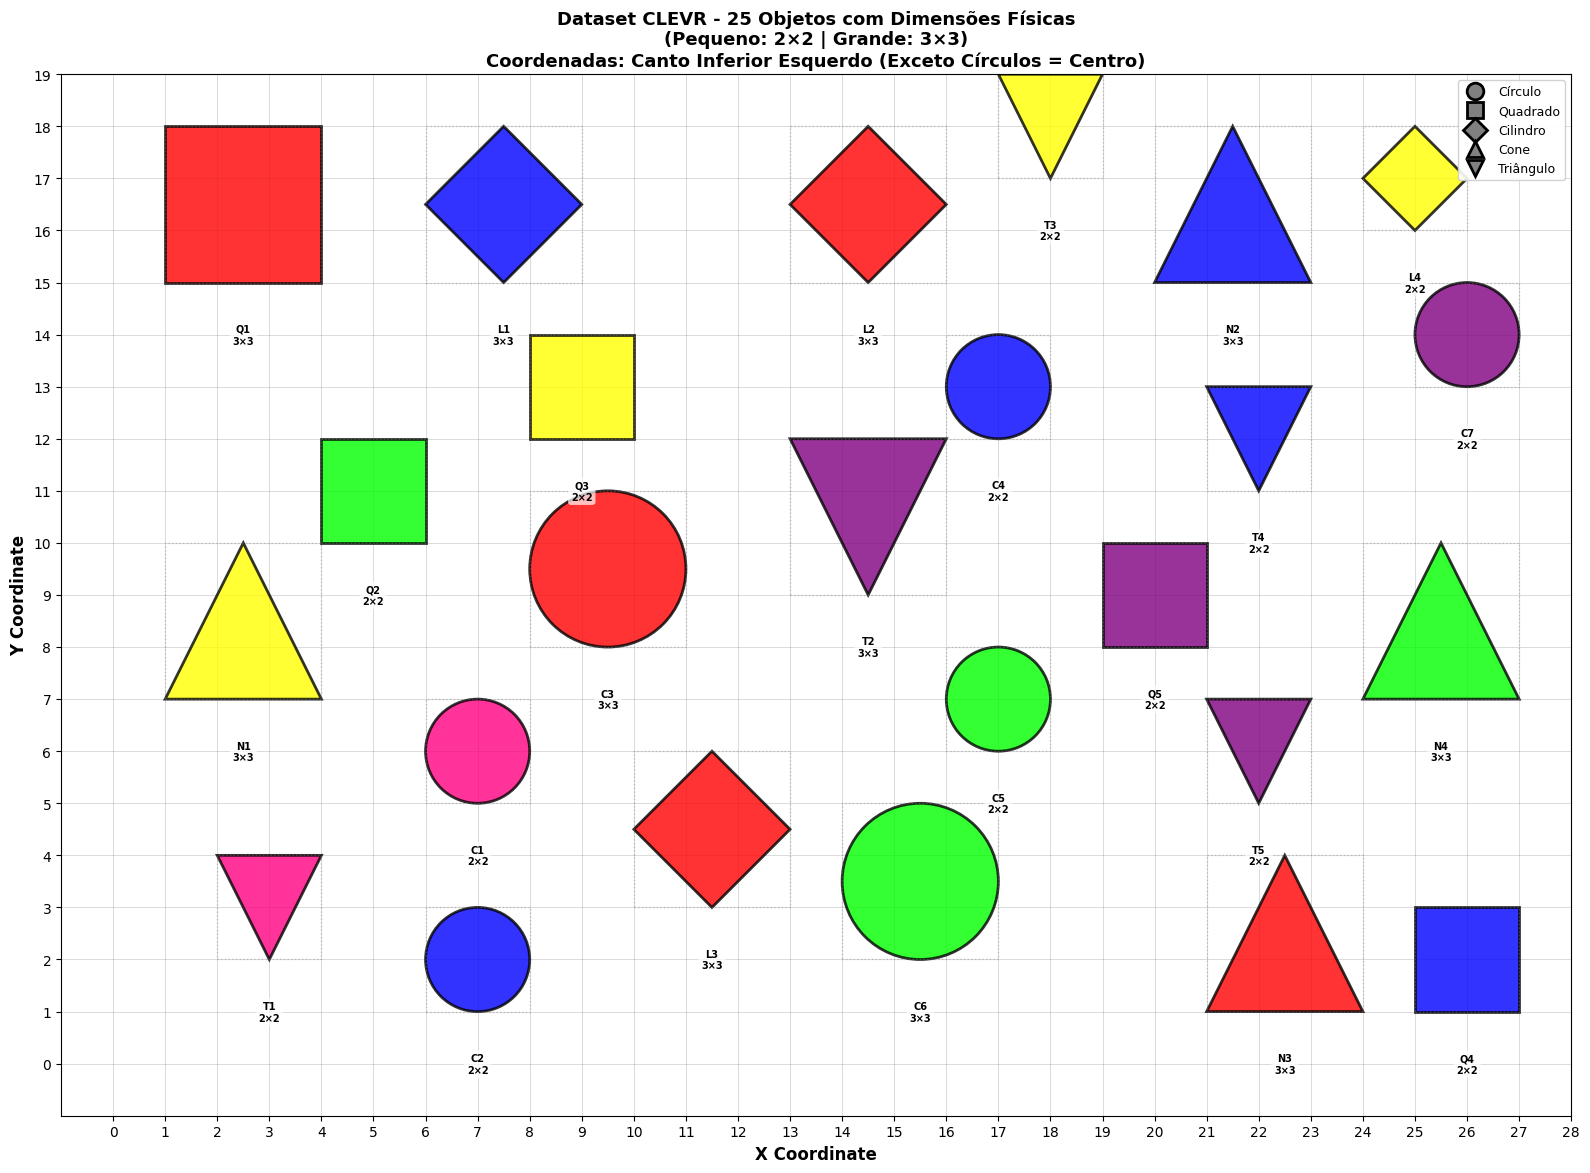


Treinamento Combinado (Forma e Tamanho)
Total de parâmetros: 6,775
Época    0 | Sat Total: 0.6066 | Forma: 0.6552 | Tamanho: 0.4935
Época   50 | Sat Total: 0.6360 | Forma: 0.6957 | Tamanho: 0.5028
Época  100 | Sat Total: 0.7879 | Forma: 0.9016 | Tamanho: 0.5430
Época  150 | Sat Total: 0.9149 | Forma: 0.9874 | Tamanho: 0.7554
Época  200 | Sat Total: 0.9815 | Forma: 0.9875 | Tamanho: 0.9170
Época  250 | Sat Total: 0.9922 | Forma: 0.9964 | Tamanho: 0.9705
Época  300 | Sat Total: 0.9838 | Forma: 0.9981 | Tamanho: 0.9910
Época  350 | Sat Total: 0.9971 | Forma: 0.9988 | Tamanho: 0.9950
Época  400 | Sat Total: 0.9987 | Forma: 0.9985 | Tamanho: 0.9948
Época  450 | Sat Total: 0.9989 | Forma: 0.9991 | Tamanho: 0.9959
Época  499 | Sat Total: 0.9990 | Forma: 0.9846 | Tamanho: 0.9980

Treinamento concluído! Satisfação final: 0.9990

Raciocínio Espacial Horizontal:

TREINAMENTO: RACIOCÍNIO ESPACIAL HORIZONTAL
Parâmetros: 8,194
Época    0 | Sat: 0.5816 | Loss: 0.4184
Época  100 | Sat: 0.6687 | Loss:

In [103]:
def main():
    print("\n" + "="*70)
    print("LTN - Dataset Fixo")
    print("="*70)

    # Carregar dataset FIXO
    data, labels, dimensions = load_fixed_clevr_dataset()

    # Visualizar cenário
    print("\n📊 Visualizando cenário...")
    plot_scene(data, labels, dimensions)

    # Treinar TODOS os predicados
    history = train_all_predicates(data, epochs=500, lr=0.001)

    # Tarefa 2: Raciocínio Horizontal
    history_spatial, results_spatial = run_task2_complete(data, labels)

    # Tarefa 3: Raciocínio Vertical
    history_vertical, results_vertical = run_task3_complete(data, labels)

    # Tarefa 4: Raciocínio Composto
    print("\n" + "="*70)
    print("TAREFA 4: RACIOCÍNIO COMPOSTO")
    print("="*70)

    with torch.no_grad():
        # Query 1: Filtragem Composta
        result1 = query_compound_filtering(data)
        print(f"\n🔍 Query 1 - Existe objeto Pequeno abaixo de Cilindro e à esquerda de Quadrado?")
        print(f"   Resultado: {result1.item():.4f} ({'SIM' if result1.item() > 0.5 else 'NÃO'})")

        # Query 2: Cone Verde Entre
        result2 = query_green_cone_between(data)
        print(f"\n🔍 Query 2 - Existe Cone Verde entre dois objetos?")
        print(f"   Resultado: {result2.item():.4f} ({'SIM' if result2.item() > 0.5 else 'NÃO'})")

        # Query 3: Triângulos Próximos Mesmo Tamanho
        result3 = query_triangles_close_same_size(data)
        print(f"\n🔍 Query 3 - Triângulos próximos têm mesmo tamanho?")
        print(f"   Resultado: {result3.item():.4f} (Satisfação da Regra)")

    print("\n" + "="*70)
    print("✅ EXECUÇÃO COMPLETA COM DATASET FIXO!")
    print("="*70)
    print("\n📊 RESUMO DE RESULTADOS:")
    print(f"  Tarefa 1 (Formas): Satisfação = {history['sat'][-1]:.4f}")
    print(f"  Tarefa 2 (Horizontal): Satisfação = {history_spatial['sat'][-1]:.4f}")
    print(f"  Tarefa 3 (Vertical): Satisfação = {history_vertical['sat'][-1]:.4f}")


if __name__ == "__main__":
    main()

# 7 - Testes em 5 Datasets

Este trecho reúne utilitários para **avaliar previsões** (hard e soft) e um **roteiro de teste** em múltiplos datasets sintéticos (estilo CLEVR), cobrindo:  
- **Classificação de Atributos** (forma e tamanho)  
- **Predicados Relacionais** (espaciais) e **Raciocínio Composto**  
- **Visualização** dos objetos gerados

## Funções de métricas —

- **`calc_binary_metrics_from_labels(pred_labels, gt_labels)`**  
  Calcula métricas binárias a partir de **rótulos 0/1**:
  - `accuracy`, `precision`, `recall`, `f1`  
  Usa `zero_division=0` para evitar exceções em casos sem positivos.

- **`soft_precision_recall_f1(pred_scores, gt_binary, eps=1e-8)`**  
  Versão “soft” de Precision/Recall/F1 usando **scores contínuos (0–1)** ao invés de threshold fixo.  
  A ideia é computar TP/FP/FN ponderados por score:
  - `tp = Σ(score * gt)`
  - `fp = Σ(score * (1-gt))`
  - `fn = Σ((1-score) * gt)`  
  `eps` evita divisão por zero.

- **`logic_metrics(pred_scores, gt_binary)`**  
  Avalia previsões (geralmente de predicados lógicos) retornando:
  - **SatAgg**: `mean(pred_scores)` (grau médio de satisfação)
  - `accuracy/precision/recall/f1` após **threshold 0.5** para obter rótulos.

## Visualização do Dataset —

- **`plot_dataset(data, labels, dataset_num)`**  
  Plota os objetos do dataset em uma grade, desenhando cada objeto em (x,y) com:
  - **cor RGB pura** (one-hot)
  - **forma** (`circle`, `square`, `cylinder`, `cone`, `triangle`)
  - **tamanho** (`small` / `big`, via `size > 0.5`)  

  A renderização usa patches do Matplotlib (`Circle`, `Rectangle`, `Polygon`) e adiciona um rótulo textual com `(shape, color, size)`.

## Pipeline de Teste (5 datasets) —

O loop executa `dataset_num = 1..5` e, para cada dataset:

1. **Geração e normalização de cor**
   - Gera `data, labels` com `generate_random_clevr_dataset(n_objects=25, seed=dataset_num)`.
   - Converte `data[:, 2:5]` (RGB) para **one-hot puro** via `argmax`, zerando os demais canais.
   - (Opcional) atualiza `labels["color"]` para `red/green/blue`.

2. **Visualização**
   - Chama `plot_dataset(...)` para inspeção rápida do dataset.

3. **Formas — Multiclasse (HARD)**
   - Calcula scores por classe com predicados (`isCircle`, `isSquare`, `isCylinder`, `isCone`, `isTriangle`), formando `shape_preds` com shape `(N, 5)`.
   - Predição hard via `argmax`, avaliando `accuracy` e `precision/recall/f1` **macro**.

4. **Formas — One-vs-Rest (SOFT)**
   - Para cada classe, avalia `soft_precision_recall_f1(scores_da_classe, gt_binario)` para medir desempenho **sem discretização hard**.

5. **Tamanhos — Binário**
   - Obtém scores com `isSmall` e `isBig`.
   - Threshold 0.5 para gerar rótulos e avalia com `calc_binary_metrics_from_labels`.

6. **Raciocínio espacial (predicados relacionais)**
   - Computa ground-truth para relações:
     - horizontal: `leftOf`, `rightOf`, `closeTo`
     - vertical: `above`, `below`
   - Varre todos os pares `(i, j)` com `i != j`, coletando `preds` e `gts`.
   - Reporta **SatAgg** + `accuracy/precision/recall/f1` via `logic_metrics`.

7. **Raciocínio composto**
   - Avalia `inBetween(i, j, k)` varrendo triplas distintas.
   - Executa queries compostas e imprime score final:
     - `query_compound_filtering`
     - `query_green_cone_between`
     - `query_triangles_close_same_size`

8. **Cache para explicabilidade**
   - Salva dados, predições, rótulos e matrizes relacionais em `explanation_cache` para depuração/análises posteriores.


DATASET 1/5


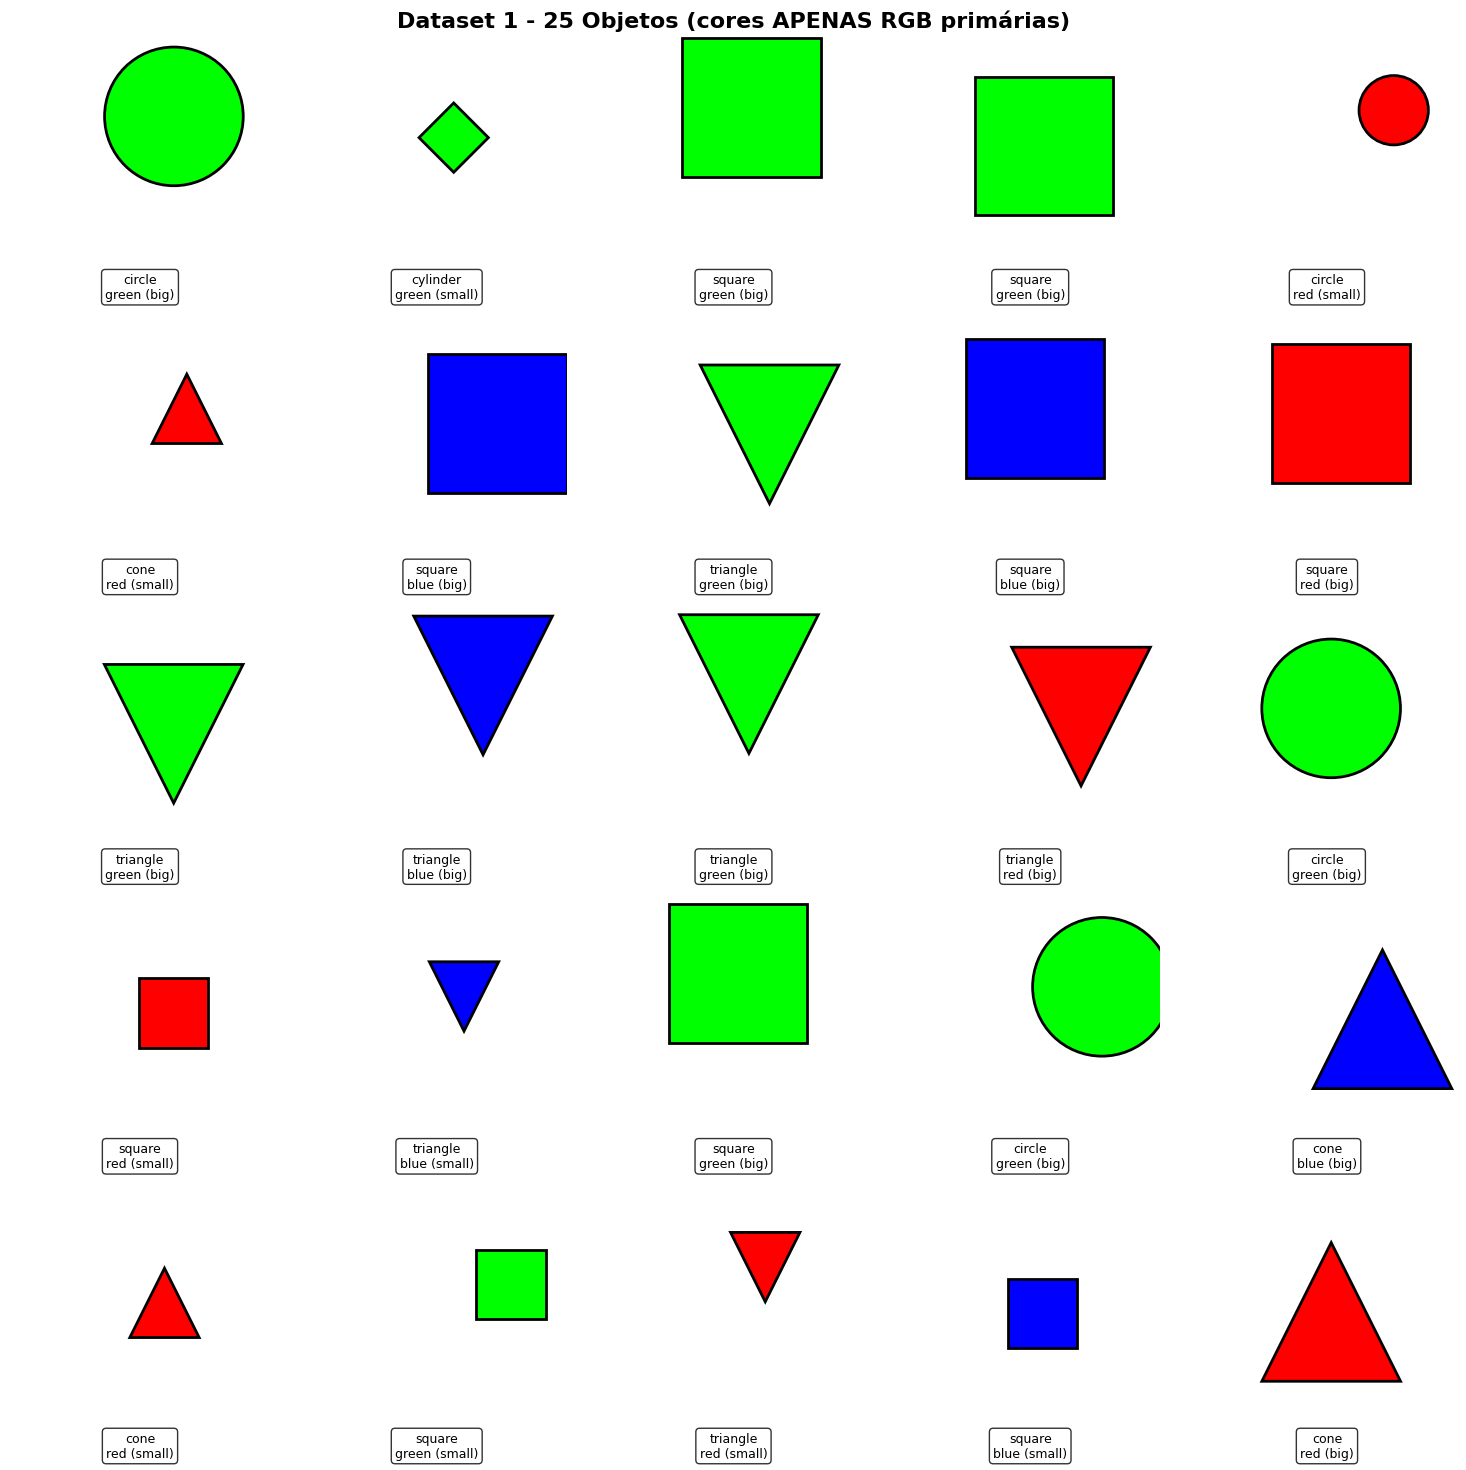


╤ FORMAS — MULTICLASSE (HARD)
Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

╤ FORMAS — ONE-vs-REST (SOFT)
circle     | Prec 99.72% | Rec 99.98% | F1 99.85%
square     | Prec 98.63% | Rec 99.98% | F1 99.30%
cylinder   | Prec 98.59% | Rec 99.93% | F1 99.26%
cone       | Prec 96.57% | Rec 99.74% | F1 98.13%
triangle   | Prec 99.95% | Rec 98.31% | F1 99.13%

╥ TAMANHOS — BINÁRIO
SMALL  | Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%
BIG    | Acc 96.00% | Prec 94.12% | Rec 100.00% | F1 96.97%

📊 Estatísticas do Ground Truth Vertical:
  Pares 'below' encontrados: 300 de 600 possíveis
  Pares 'above' encontrados: 300 de 600 possíveis

​ RACIOCÍNIO ESPACIAL — HORIZONTAL
leftOf   | Sat 0.194 | Acc 63.00% | Prec 89.00% | Rec 29.67% | F1 44.50%
rightOf  | Sat 0.175 | Acc 57.67% | Prec 76.14% | Rec 22.33% | F1 34.54%
closeTo  | Sat 0.697 | Acc 58.00% | Prec 48.78% | Rec 100.00% | F1 65.57%

​ RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)
inBetween | Sat 0.044 | Acc 66.92% | Prec 55.

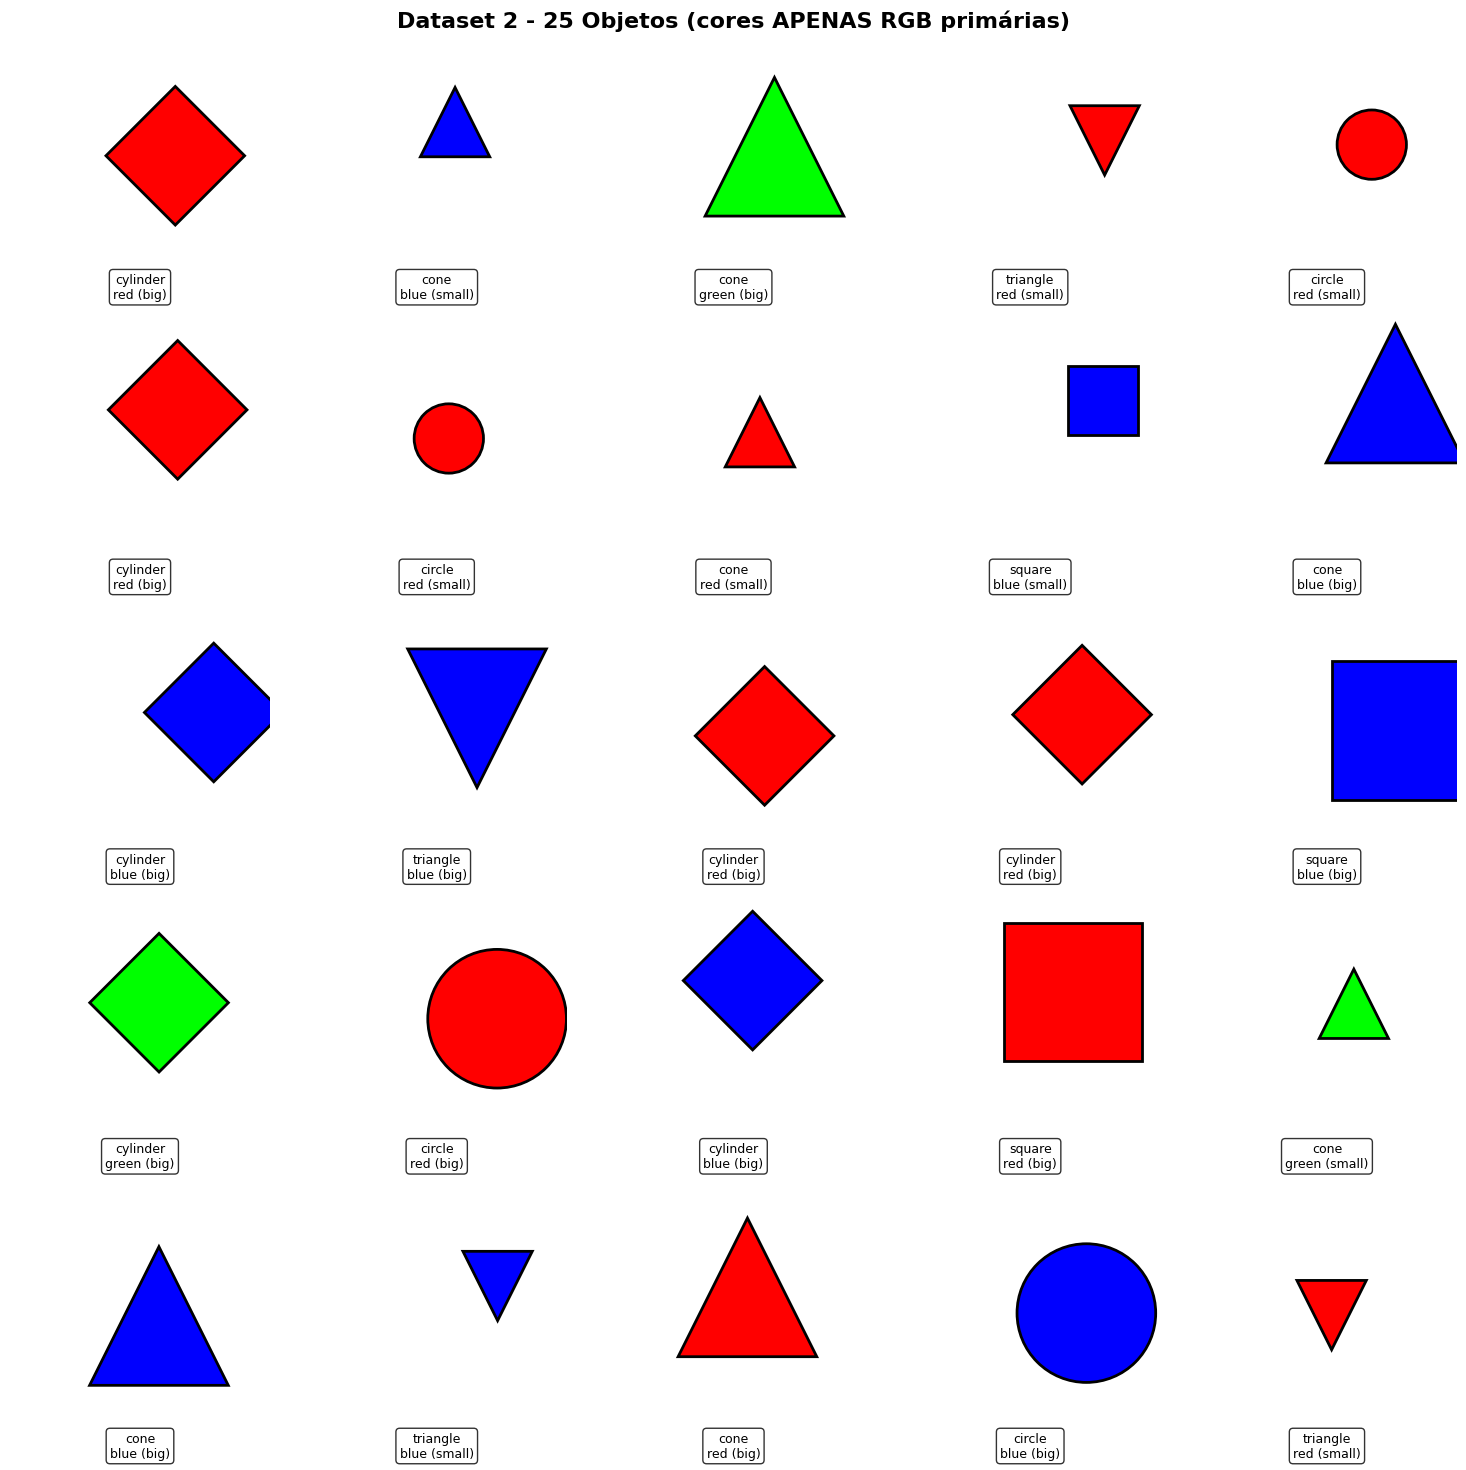


╤ FORMAS — MULTICLASSE (HARD)
Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

╤ FORMAS — ONE-vs-REST (SOFT)
circle     | Prec 99.88% | Rec 99.99% | F1 99.94%
square     | Prec 98.40% | Rec 99.98% | F1 99.19%
cylinder   | Prec 99.93% | Rec 99.96% | F1 99.95%
cone       | Prec 99.86% | Rec 99.92% | F1 99.89%
triangle   | Prec 99.90% | Rec 99.98% | F1 99.94%

╥ TAMANHOS — BINÁRIO
SMALL  | Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%
BIG    | Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

📊 Estatísticas do Ground Truth Vertical:
  Pares 'below' encontrados: 300 de 600 possíveis
  Pares 'above' encontrados: 300 de 600 possíveis

​ RACIOCÍNIO ESPACIAL — HORIZONTAL
leftOf   | Sat 0.098 | Acc 57.50% | Prec 97.87% | Rec 15.33% | F1 26.51%
rightOf  | Sat 0.125 | Acc 56.50% | Prec 83.05% | Rec 16.33% | F1 27.30%
closeTo  | Sat 0.714 | Acc 62.67% | Prec 55.02% | Rec 100.00% | F1 70.98%

​ RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)
inBetween | Sat 0.010 | Acc 66.63% | Prec 

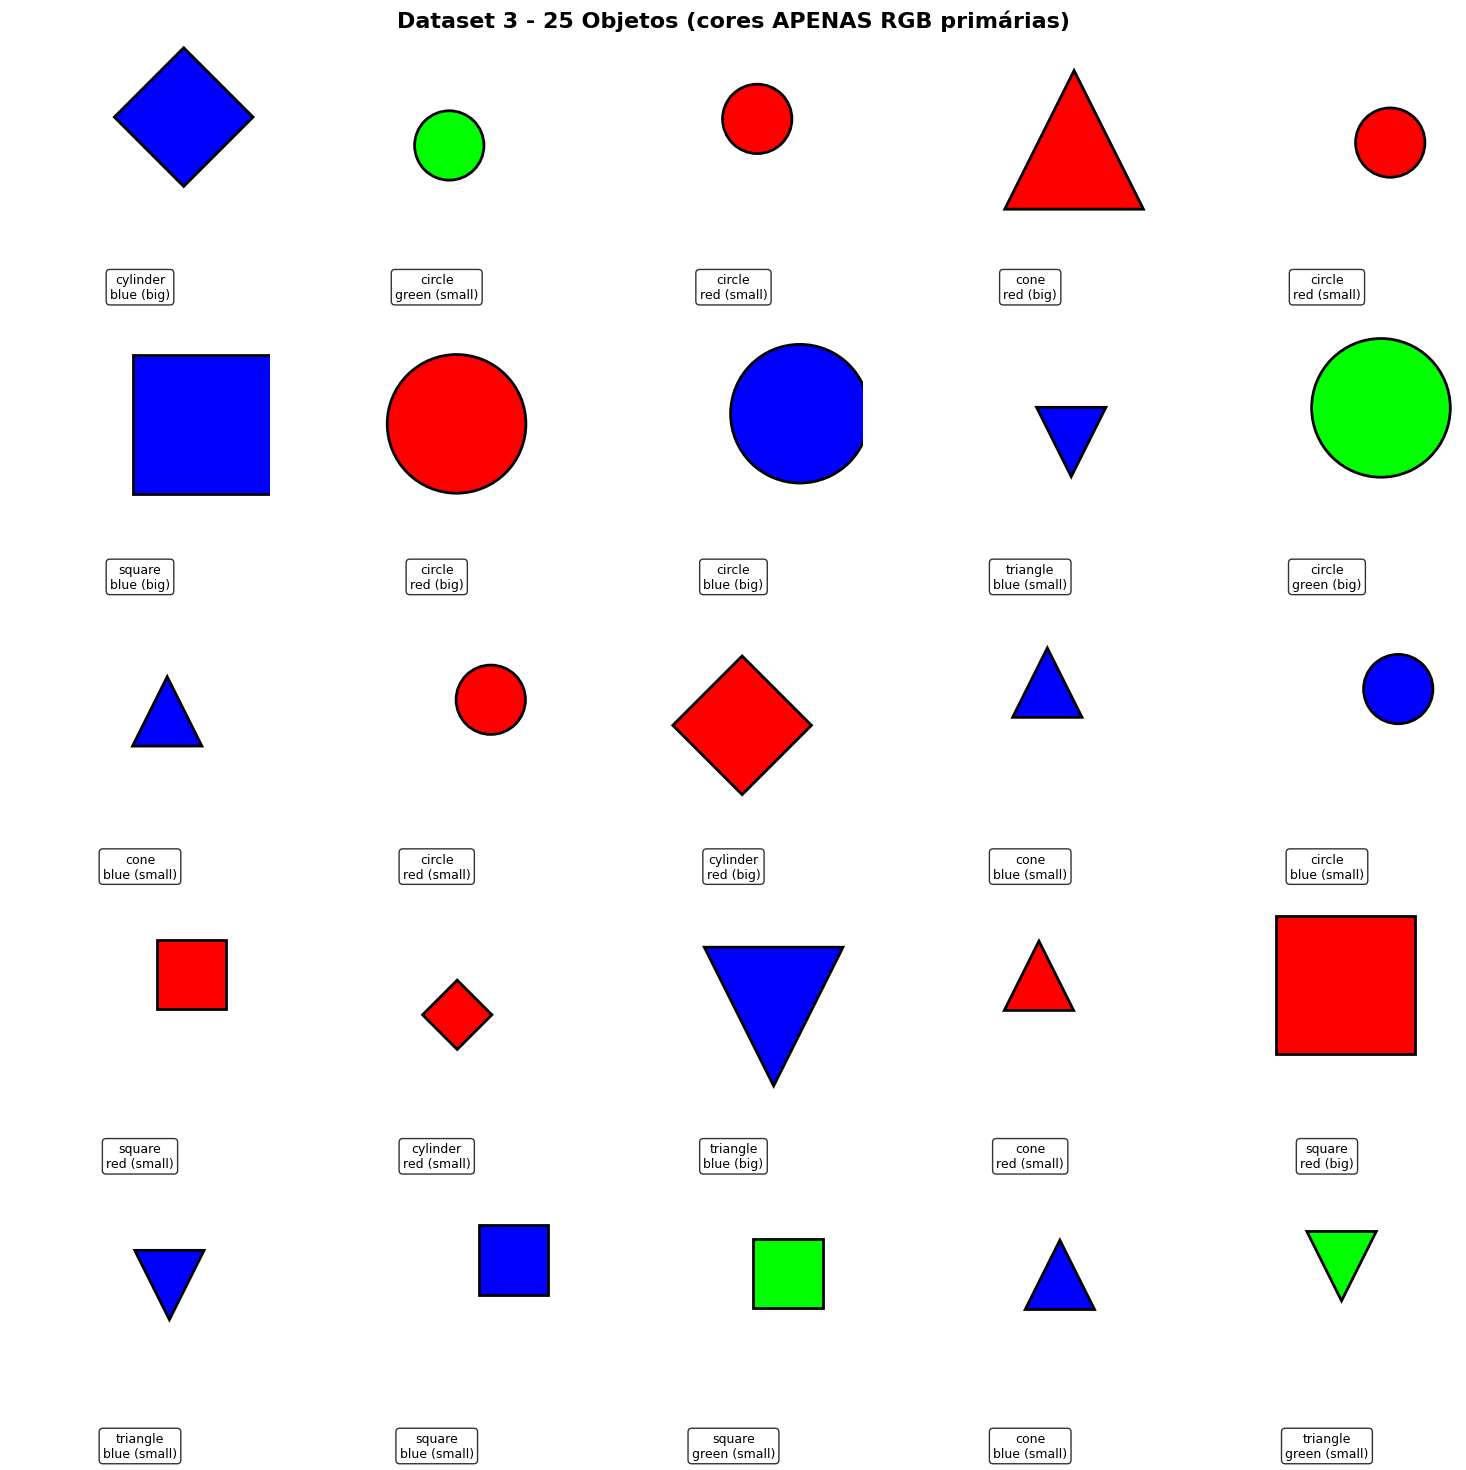


╤ FORMAS — MULTICLASSE (HARD)
Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

╤ FORMAS — ONE-vs-REST (SOFT)
circle     | Prec 99.83% | Rec 99.97% | F1 99.90%
square     | Prec 98.32% | Rec 99.98% | F1 99.15%
cylinder   | Prec 99.80% | Rec 99.95% | F1 99.88%
cone       | Prec 99.80% | Rec 99.62% | F1 99.71%
triangle   | Prec 99.76% | Rec 99.97% | F1 99.87%

╥ TAMANHOS — BINÁRIO
SMALL  | Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%
BIG    | Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

📊 Estatísticas do Ground Truth Vertical:
  Pares 'below' encontrados: 300 de 600 possíveis
  Pares 'above' encontrados: 300 de 600 possíveis

​ RACIOCÍNIO ESPACIAL — HORIZONTAL
leftOf   | Sat 0.134 | Acc 60.83% | Prec 94.52% | Rec 23.00% | F1 37.00%
rightOf  | Sat 0.166 | Acc 63.17% | Prec 92.47% | Rec 28.67% | F1 43.77%
closeTo  | Sat 0.723 | Acc 60.67% | Prec 53.36% | Rec 100.00% | F1 69.59%

​ RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)
inBetween | Sat 0.023 | Acc 67.46% | Prec 

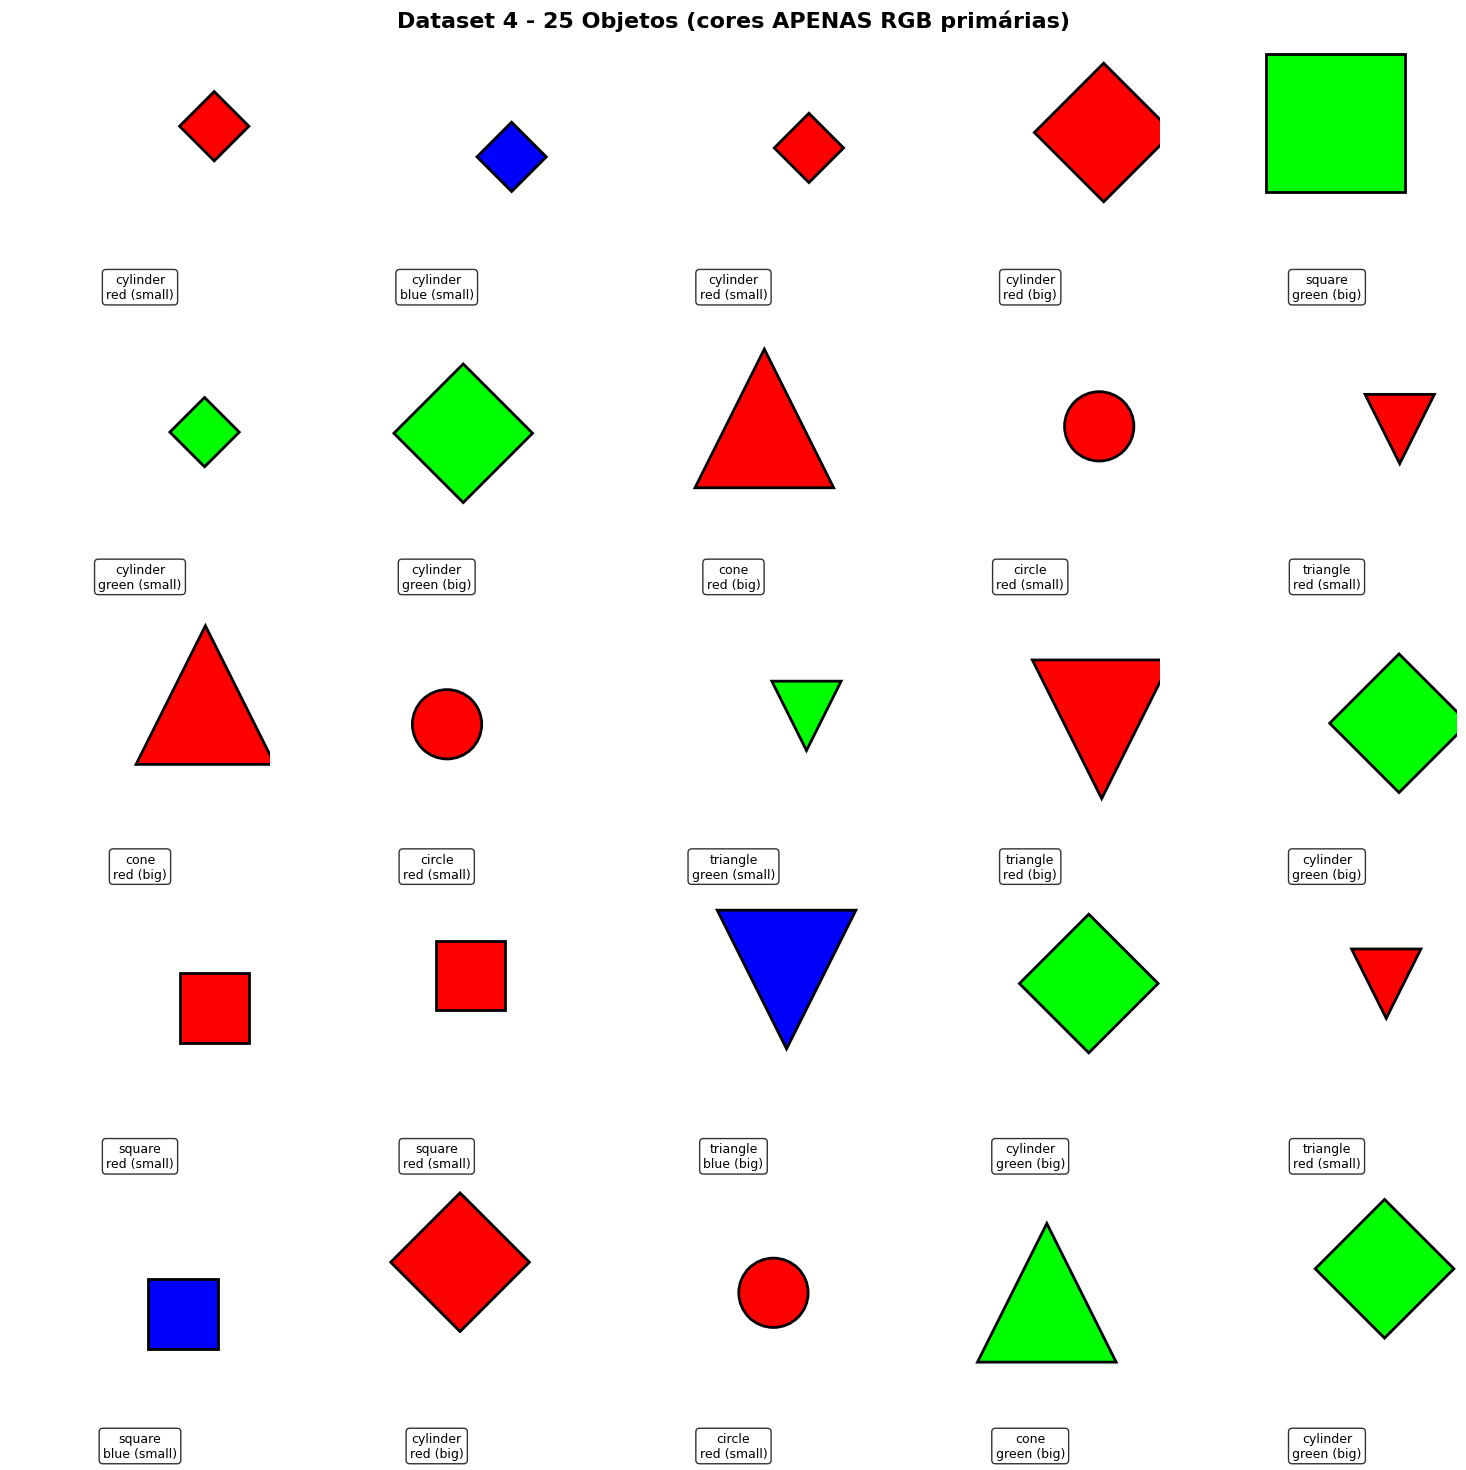


╤ FORMAS — MULTICLASSE (HARD)
Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

╤ FORMAS — ONE-vs-REST (SOFT)
circle     | Prec 99.73% | Rec 100.00% | F1 99.87%
square     | Prec 99.90% | Rec 99.99% | F1 99.94%
cylinder   | Prec 99.90% | Rec 99.93% | F1 99.91%
cone       | Prec 99.46% | Rec 99.88% | F1 99.67%
triangle   | Prec 99.94% | Rec 99.93% | F1 99.94%

╥ TAMANHOS — BINÁRIO
SMALL  | Acc 96.00% | Prec 92.86% | Rec 100.00% | F1 96.30%
BIG    | Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

📊 Estatísticas do Ground Truth Vertical:
  Pares 'below' encontrados: 300 de 600 possíveis
  Pares 'above' encontrados: 300 de 600 possíveis

​ RACIOCÍNIO ESPACIAL — HORIZONTAL
leftOf   | Sat 0.178 | Acc 64.67% | Prec 96.81% | Rec 30.33% | F1 46.19%
rightOf  | Sat 0.189 | Acc 61.00% | Prec 82.35% | Rec 28.00% | F1 41.79%
closeTo  | Sat 0.707 | Acc 61.67% | Prec 52.08% | Rec 100.00% | F1 68.49%

​ RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)
inBetween | Sat 0.033 | Acc 66.76% | Prec 52

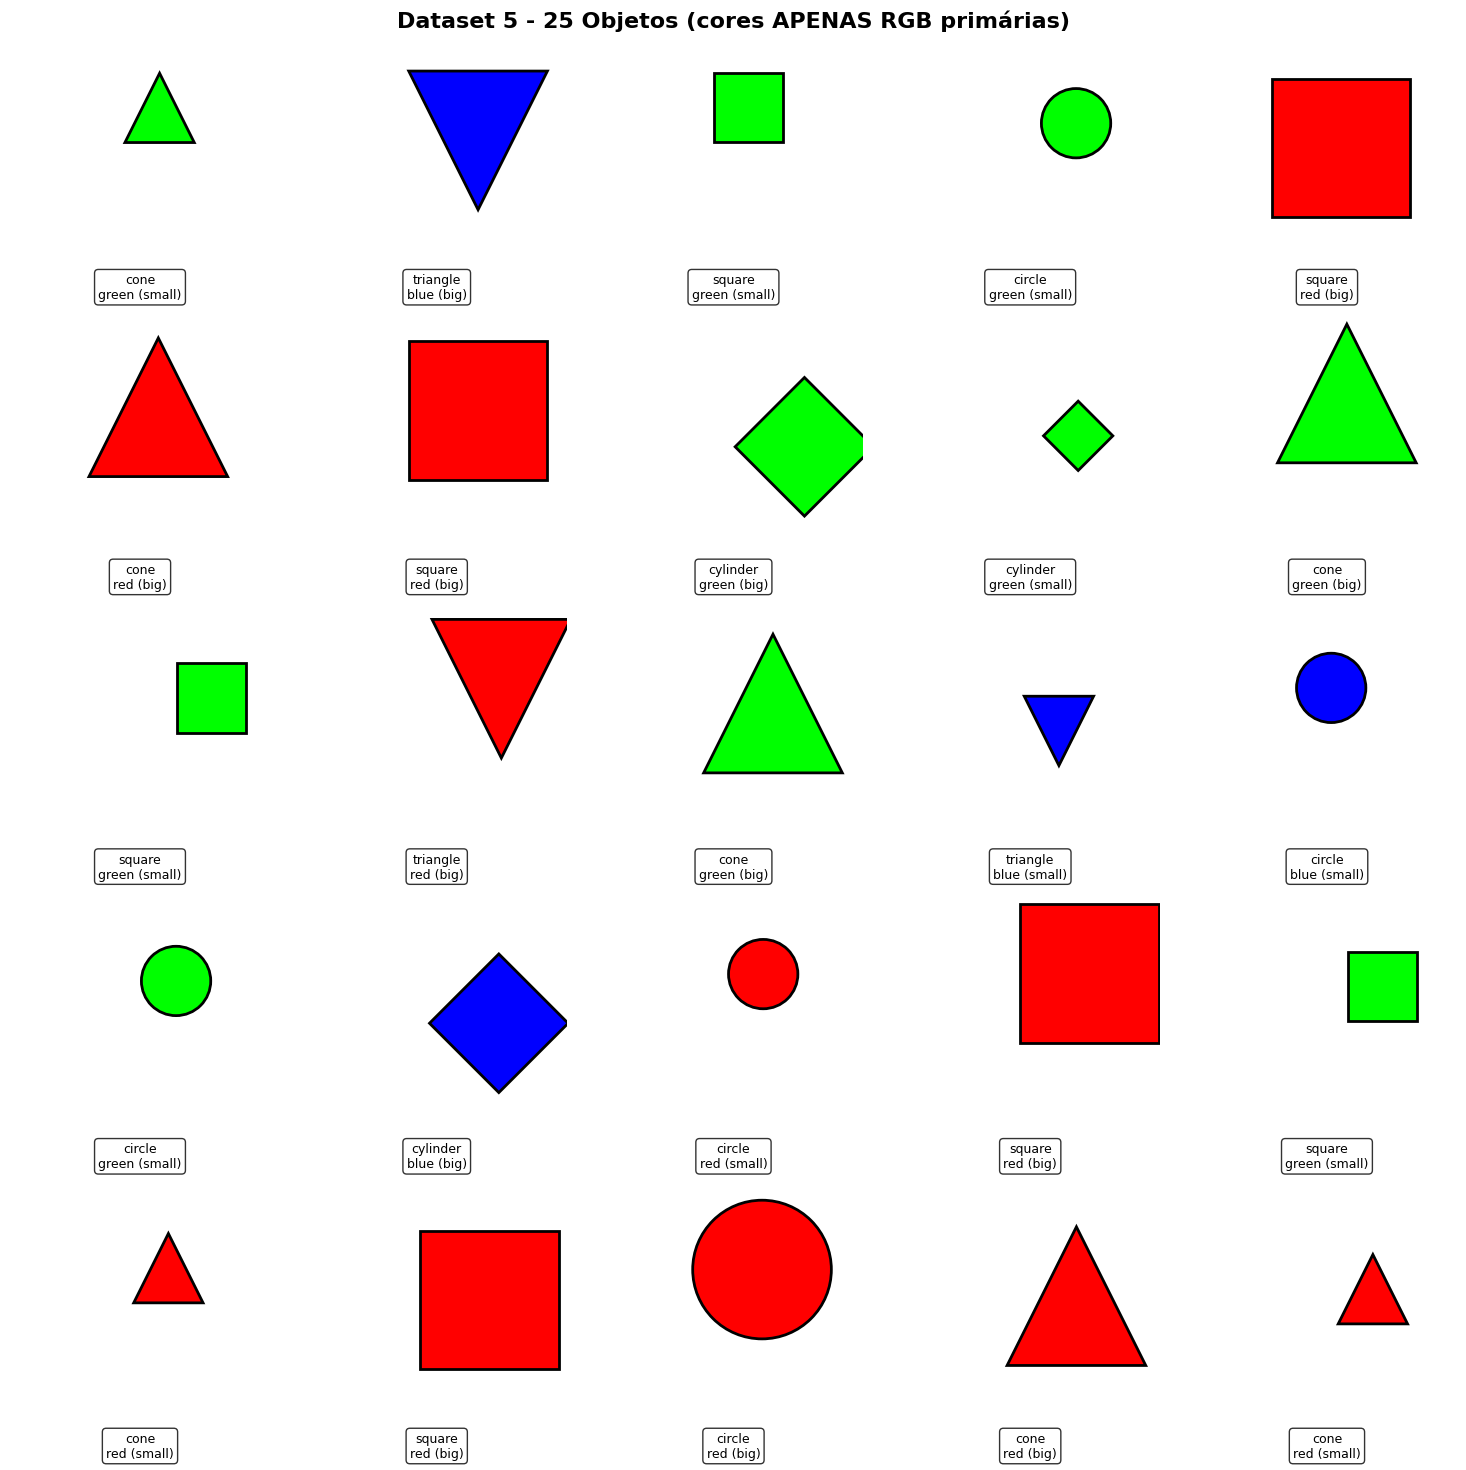


╤ FORMAS — MULTICLASSE (HARD)
Acc 100.00% | Prec 100.00% | Rec 100.00% | F1 100.00%

╤ FORMAS — ONE-vs-REST (SOFT)
circle     | Prec 99.91% | Rec 99.98% | F1 99.95%
square     | Prec 99.75% | Rec 99.96% | F1 99.85%
cylinder   | Prec 99.93% | Rec 99.97% | F1 99.95%
cone       | Prec 99.68% | Rec 99.85% | F1 99.77%
triangle   | Prec 99.85% | Rec 99.97% | F1 99.91%

╥ TAMANHOS — BINÁRIO
SMALL  | Acc 96.00% | Prec 92.31% | Rec 100.00% | F1 96.00%
BIG    | Acc 96.00% | Prec 92.86% | Rec 100.00% | F1 96.30%

📊 Estatísticas do Ground Truth Vertical:
  Pares 'below' encontrados: 300 de 600 possíveis
  Pares 'above' encontrados: 300 de 600 possíveis

​ RACIOCÍNIO ESPACIAL — HORIZONTAL
leftOf   | Sat 0.115 | Acc 58.33% | Prec 93.10% | Rec 18.00% | F1 30.17%
rightOf  | Sat 0.135 | Acc 56.33% | Prec 77.14% | Rec 18.00% | F1 29.19%
closeTo  | Sat 0.736 | Acc 58.33% | Prec 52.65% | Rec 100.00% | F1 68.98%

​ RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)
inBetween | Sat 0.019 | Acc 66.83% | Prec 62.64%

In [104]:
def calc_binary_metrics_from_labels(pred_labels, gt_labels):
    return (
        accuracy_score(gt_labels, pred_labels),
        precision_score(gt_labels, pred_labels, zero_division=0),
        recall_score(gt_labels, pred_labels, zero_division=0),
        f1_score(gt_labels, pred_labels, zero_division=0),
    )


def soft_precision_recall_f1(pred_scores, gt_binary, eps=1e-8):
    tp = np.sum(pred_scores * gt_binary)
    fp = np.sum(pred_scores * (1 - gt_binary))
    fn = np.sum((1 - pred_scores) * gt_binary)

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)

    return precision, recall, f1


def logic_metrics(pred_scores, gt_binary):
    pred_labels = (np.array(pred_scores) >= 0.5).astype(int)
    acc, prec, rec, f1 = calc_binary_metrics_from_labels(pred_labels, gt_binary)
    satagg = float(np.mean(pred_scores))
    return satagg, acc, prec, rec, f1


# ============================================================
# CORES: FORÇAR APENAS VERMELHO, VERDE OU AZUL
# ============================================================

def quantize_rgb_to_primary(r, g, b):
    """
    Mapeia qualquer RGB (0..1) para SOMENTE uma destas 3 cores:
    - red   = (1,0,0)
    - green = (0,1,0)
    - blue  = (0,0,1)

    Regra: escolhe o canal dominante (maior valor entre r,g,b).
    """
    r, g, b = np.clip([r, g, b], 0.0, 1.0)
    dominant = int(np.argmax([r, g, b]))

    if dominant == 0:
        return (1.0, 0.0, 0.0), "red"
    elif dominant == 1:
        return (0.0, 1.0, 0.0), "green"
    else:
        return (0.0, 0.0, 1.0), "blue"


# ============================================================
# VISUALIZAÇÃO
# ============================================================

def plot_dataset(data, labels, dataset_num):
    n_objects = data.shape[0]
    n_cols = 5
    n_rows = (n_objects + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
    fig.suptitle(
        f"Dataset {dataset_num} - {n_objects} Objetos (cores APENAS RGB primárias)",
        fontsize=16,
        fontweight="bold",
    )

    if n_rows == 1:
        axes = axes.reshape(1, -1)

    axes_flat = axes.flatten()
    shape_names = ["circle", "square", "cylinder", "cone", "triangle"]

    for idx, ax in enumerate(axes_flat):
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect("equal")
        ax.axis("off")

        if idx >= n_objects:
            continue

        obj = data[idx].cpu().numpy()
        x, y = obj[0], obj[1]

        # ✅ Extrair cores RGB reais (índices 2,3,4) e quantizar para {red, green, blue}
        r, g, b = obj[2], obj[3], obj[4]
        color_rgb, color_name = quantize_rgb_to_primary(r, g, b)

        shape_idx = int(np.argmax(obj[5:10]))
        size = obj[10]

        shape_name = shape_names[shape_idx]
        size_label = "big" if size > 0.5 else "small"
        scale = 0.8 if size_label == "big" else 0.4

        # ✅ APLICAR COR RGB (primária) aos patches
        if shape_name == "circle":
            patch = Circle((x, y), scale, facecolor=color_rgb, edgecolor="black", linewidth=2)
            ax.add_patch(patch)

        elif shape_name == "square":
            patch = Rectangle(
                (x - scale, y - scale),
                2 * scale,
                2 * scale,
                facecolor=color_rgb,
                edgecolor="black",
                linewidth=2,
            )
            ax.add_patch(patch)

        elif shape_name == "cylinder":
            # Diamante para representar cilindro
            diamond_points = [
                (x, y + scale),     # topo
                (x + scale, y),     # direita
                (x, y - scale),     # baixo
                (x - scale, y),     # esquerda
            ]
            patch = Polygon(diamond_points, facecolor=color_rgb, edgecolor="black", linewidth=2)
            ax.add_patch(patch)

        elif shape_name == "cone":
            # Triângulo apontando para cima
            triangle_points = [
                (x, y + scale),          # topo
                (x - scale, y - scale),  # esquerda
                (x + scale, y - scale),  # direita
            ]
            patch = Polygon(triangle_points, facecolor=color_rgb, edgecolor="black", linewidth=2)
            ax.add_patch(patch)

        else:  # triangle
            # Triângulo apontando para baixo
            triangle_points = [
                (x, y - scale),          # baixo
                (x - scale, y + scale),  # esquerda
                (x + scale, y + scale),  # direita
            ]
            patch = Polygon(triangle_points, facecolor=color_rgb, edgecolor="black", linewidth=2)
            ax.add_patch(patch)

        # ✅ MOSTRAR INFORMAÇÕES
        ax.text(
            0,
            -1.3,
            f"{shape_name}\n{color_name} ({size_label})",
            ha="center",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# TESTE
# ============================================================

shape_names = ["circle", "square", "cylinder", "cone", "triangle"]

explanation_cache = []

for dataset_num in range(1, 6):

    print(f"\n{'='*90}")
    print(f"DATASET {dataset_num}/5")
    print(f"{'='*90}")

    data, labels, _ = generate_random_clevr_dataset(
        n_objects=25,
        seed=dataset_num
    )

    plot_dataset(data, labels, dataset_num)

    data_d = data.to(device)
    N = data.shape[0]

    # ========================================================
    # FORMAS — MULTICLASSE (HARD)
    # ========================================================

    with torch.no_grad():
        # ✅ CORREÇÃO: Criar ltn.Variable para todo o dataset
        data_var = ltn.Variable("data_shapes", data_d)

        shape_preds = np.stack([
            isCircle(data_var).value.cpu().numpy(),
            isSquare(data_var).value.cpu().numpy(),
            isCylinder(data_var).value.cpu().numpy(),
            isCone(data_var).value.cpu().numpy(),
            isTriangle(data_var).value.cpu().numpy()
        ], axis=1)

    shape_gt = torch.argmax(data[:, 5:10], dim=1).cpu().numpy()
    shape_pred = np.argmax(shape_preds, axis=1)

    print("\n╤ FORMAS — MULTICLASSE (HARD)")
    print(f"Acc {accuracy_score(shape_gt, shape_pred):.2%} | "
          f"Prec {precision_score(shape_gt, shape_pred, average='macro'):.2%} | "
          f"Rec {recall_score(shape_gt, shape_pred, average='macro'):.2%} | "
          f"F1 {f1_score(shape_gt, shape_pred, average='macro'):.2%}")

    # ========================================================
    # FORMAS — ONE-vs-REST (SOFT)
    # ========================================================

    print("\n╤ FORMAS — ONE-vs-REST (SOFT)")

    for i, name in enumerate(shape_names):
        gt_bin = (shape_gt == i).astype(int)
        scores = shape_preds[:, i]
        prec, rec, f1 = soft_precision_recall_f1(scores, gt_bin)

        print(f"{name:10} | Prec {prec:.2%} | Rec {rec:.2%} | F1 {f1:.2%}")

    # ========================================================
    # TAMANHOS — BINÁRIO
    # ========================================================

    print("\n╥ TAMANHOS — BINÁRIO")

    with torch.no_grad():
        # ✅ CORREÇÃO: Usar ltn.Variable
        data_var_size = ltn.Variable("data_sizes", data_d)

        small_scores = isSmall(data_var_size).value.cpu().numpy()
        big_scores   = isBig(data_var_size).value.cpu().numpy()

    small_gt = (data[:, 10] < 0.5).int().cpu().numpy()
    big_gt   = (data[:, 10] >= 0.5).int().cpu().numpy()

    for name, scores, gt in [
        ("SMALL", small_scores, small_gt),
        ("BIG",   big_scores,   big_gt)
    ]:
        pred = (scores >= 0.5).astype(int)
        acc, prec, rec, f1 = calc_binary_metrics_from_labels(pred, gt)

        print(f"{name:6} | Acc {acc:.2%} | Prec {prec:.2%} | Rec {rec:.2%} | F1 {f1:.2%}")

    # ========================================================
    # RACIOCÍNIO LÓGICO
    # ========================================================

    gt_spatial = compute_spatial_ground_truth(data)
    gt_left  = gt_spatial["leftOf"]
    gt_right = gt_spatial["rightOf"]
    gt_close = gt_spatial["closeTo"]

    gt_vertical = compute_vertical_ground_truth(data)
    gt_above = gt_vertical["above"]
    gt_below = gt_vertical["below"]

    print("\n​ RACIOCÍNIO ESPACIAL — HORIZONTAL")

    for name, pred_fun, gt_mat in [
        ("leftOf", leftOf, gt_left),
        ("rightOf", rightOf, gt_right),
        ("closeTo", closeTo, gt_close)
    ]:
        preds, gts = [], []
        with torch.no_grad():
            for i in range(N):
                for j in range(N):
                    if i == j:
                        continue

                    # ✅ CORREÇÃO: Criar Variables LTN
                    x_var = ltn.Variable(f"x_{name}_{i}", data_d[i:i+1])
                    y_var = ltn.Variable(f"y_{name}_{j}", data_d[j:j+1])

                    pred_result = pred_fun(x_var, y_var)

                    # Extrair valor
                    if hasattr(pred_result, 'value'):
                        pred = pred_result.value
                    else:
                        pred = pred_result

                    if torch.is_tensor(pred):
                        if pred.dim() > 0:
                            pred = pred.mean().item()
                        else:
                            pred = pred.item()

                    preds.append(float(pred))
                    gts.append(int(gt_mat[(i, j)]))

        sat, acc, prec, rec, f1 = logic_metrics(preds, gts)
        print(f"{name:8} | Sat {sat:.3f} | Acc {acc:.2%} | Prec {prec:.2%} | Rec {rec:.2%} | F1 {f1:.2%}")

    print("\n​ RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)")

    preds, gts = [], []
    with torch.no_grad():
        for i in range(N):
            for j in range(N):
                for k in range(N):
                    if len({i, j, k}) < 3:
                        continue

                    # ✅ CORREÇÃO: Passar tensores diretos (inBetween já lida internamente)
                    pred_result = inBetween(data_d[i], data_d[j], data_d[k])

                    if hasattr(pred_result, 'value'):
                        pred = pred_result.value
                    else:
                        pred = pred_result

                    if torch.is_tensor(pred):
                        if pred.dim() > 0:
                            pred = pred.mean().item()
                        else:
                            pred = pred.item()

                    preds.append(float(pred))

                    gt = (
                        (gt_left[(j, i)] and gt_right[(k, i)]) or
                        (gt_left[(k, i)] and gt_right[(j, i)])
                    )
                    gts.append(int(gt))

    sat, acc, prec, rec, f1 = logic_metrics(preds, gts)
    print(f"inBetween | Sat {sat:.3f} | Acc {acc:.2%} | Prec {prec:.2%} | Rec {rec:.2%} | F1 {f1:.2%}")

    print("\n​ RACIOCÍNIO ESPACIAL — VERTICAL")

    for name, pred_fun, gt_mat in [
        ("above", above, gt_above),
        ("below", below, gt_below)
    ]:
        preds, gts = [], []
        with torch.no_grad():
            for i in range(N):
                for j in range(N):
                    if i == j:
                        continue

                    # ✅ CORREÇÃO: Criar Variables LTN
                    x_var = ltn.Variable(f"x_{name}_{i}", data_d[i:i+1])
                    y_var = ltn.Variable(f"y_{name}_{j}", data_d[j:j+1])

                    pred_result = pred_fun(x_var, y_var)

                    if hasattr(pred_result, 'value'):
                        pred = pred_result.value
                    else:
                        pred = pred_result

                    if torch.is_tensor(pred):
                        if pred.dim() > 0:
                            pred = pred.mean().item()
                        else:
                            pred = pred.item()

                    preds.append(float(pred))
                    gts.append(int(gt_mat[(i, j)]))

        sat, acc, prec, rec, f1 = logic_metrics(preds, gts)
        print(f"{name:6} | Sat {sat:.3f} | Acc {acc:.2%} | Prec {prec:.2%} | Rec {rec:.2%} | F1 {f1:.2%}")

    # ========================================================
    # RACIOCÍNIO COMPOSTO
    # ========================================================

    print("\n📊 RACIOCÍNIO COMPOSTO")

    with torch.no_grad():
        # Query 1
        q1_result = query_compound_filtering(data)
        q1_score = q1_result.item() if torch.is_tensor(q1_result) else q1_result
        print(f"Query 1 (Pequeno ∧ Below(Cilindro) ∧ Left(Quadrado)): {q1_score:.3f}")

        # Query 2
        q2_result = query_green_cone_between(data)
        q2_score = q2_result.item() if torch.is_tensor(q2_result) else q2_result
        print(f"Query 2 (Cone Verde Entre): {q2_score:.3f}")

        # Query 3
        q3_result = query_triangles_close_same_size(data)
        q3_score = q3_result.item() if torch.is_tensor(q3_result) else q3_result
        print(f"Query 3 (Triângulos Próximos → Mesmo Tamanho): {q3_score:.3f}")

    # ========================================================
    # ARMAZENAMENTO PARA EXPLICABILIDADE
    # ========================================================

    explanation_cache.append({
        "dataset": dataset_num,
        "data": data,
        "data_d": data_d,
        "shape_preds": shape_preds,
        "shape_gt": shape_gt,
        "small_preds": small_scores,
        "big_preds": big_scores,
        "small_gt": small_gt,
        "gt_left": gt_left,
        "gt_right": gt_right,
        "gt_above": gt_above,
        "gt_below": gt_below
    })

print("\n" + "="*90)
print("✅ TESTE COM 5 DATASETS CONCLUÍDO!")
print("="*90)

# 8 - Explicabilidade em Linguagem Natural

Este trecho gera **explicações textuais** (em linguagem natural) para o raciocínio do modelo sobre os **5 datasets de teste**, usando os resultados previamente armazenados em `explanation_cache`. A saída é organizada por dataset e cobre:

- **Formas** (explicando a classe prevista e o score associado)
- **Tamanhos** (comparando os graus de verdade de `small` vs `big`)
- **Raciocínio espacial** (horizontal, vertical e composto via `inBetween`)
- **Raciocínio composto** (queries de maior nível que combinam predicados)

## 1) Deduplicação de experimentos -

Como `explanation_cache` pode conter entradas repetidas, o código cria um dicionário `unique_experiments` indexado por `dataset`, garantindo que **cada dataset apareça uma única vez**:

- chave: `exp["dataset"]`
- valor: o próprio dicionário `exp` com dados, predições e ground-truth

Em seguida, imprime um cabeçalho e percorre os datasets em ordem crescente.

## 2) Recuperação de artefatos do cache -

Para cada `dataset_id`, o código recupera do cache:

- `data`, `data_d`: dados no CPU e no dispositivo (ex.: GPU), respectivamente
- `shape_preds`, `shape_gt`: scores por forma (N×5) e rótulo verdadeiro (argmax)
- `small_preds`, `big_preds`, `small_gt`: scores de tamanho e ground-truth binário
- matrizes de ground-truth relacional: `gt_left`, `gt_right`, `gt_above` (e outras se existirem)

Essas variáveis são usadas para compor as explicações em texto.

## 3) Explicações para formas -

Para os **primeiros 2 objetos** do dataset (ou menos, se `len(data) < 2`), o código:

- escolhe a classe prevista com `pred = argmax(shape_preds[i])`
- imprime uma justificativa do tipo:
  - “foi classificado como X porque teve a maior ativação para essa forma (score)”
- também informa o **rótulo verdadeiro** (`shape_gt[i]`) para comparação.

## 4) Explicações para tamanhos -

Para os **primeiros 2 objetos**, o código decide o tamanho previsto comparando os scores:

- `pred = "small"` se `small_p[i] >= big_p[i]`, senão `"big"`
- reporta o **grau de verdade vencedor** (`max(small_p[i], big_p[i])`)
- exibe também o tamanho real a partir de `small_gt[i]`:
  - `small` se `small_gt[i] == 1`
  - `big` caso contrário

## 5) Helper para converter um objeto em `ltn.Constant` -

Objetivo: transformar a linha `idx` do dataset em um objeto consumível pelos predicados LTN.

Comportamento:
- se `data_d_like` já for um `LTNObject` (tem `.value`), usa o tensor interno
- seleciona a linha `idx`
- garante o shape `[1, features]` (`unsqueeze(0)` se necessário)
- retorna `ltn.Constant(row)`

Isso facilita chamar predicados como `leftOf(di, dj)`/`above(di, dj)`/`inBetween(di, dj, dk)`.

## 6) Raciocínio espacial — Horizontal (`leftOf`) -

O exemplo usa os objetos `i=0` e `j=1`:
- extrai `xi = x(i)` e `xj = x(j)` a partir de `data`
- calcula `score = leftOf(di, dj)` com `torch.no_grad()`

A explicação compara:
- **decisão do modelo** (`score >= 0.5` → verdadeiro/falso)
- **justificativa geométrica** (comparação entre `xi` e `xj`)
- **ground-truth** `gt_left[i, j]` como “valor geométrico real”

## 7 Raciocínio espacial — Composto (`inBetween`) -

O exemplo usa `i=0`, `j=1`, `k=2`:
- extrai `x(i)`, `x(j)`, `x(k)`
- computa `score = inBetween(di, dj, dk)`

Em seguida, traduz a condição lógica em termos geométricos:
- `cond1 = (xj < xi < xk)`
- `cond2 = (xk < xi < xj)`

A explicação descreve o “ou… ou…” do predicado e afirma se, **pelos valores de x**, a proposição é verdadeira ou falsa.

## 8) Raciocínio espacial — Vertical (`above`) -

Com `i=0`, `j=1`:
- extrai `yi = y(i)` e `yj = y(j)`
- computa `score = above(di, dj)`

A explicação segue o mesmo padrão do horizontal:
- decisão por threshold (verdadeiro/falso)
- comparação geométrica `yi > yj`
- ground-truth `gt_above[i, j]`

## 9) Raciocínio composto (Queries) -

Executa três queries (sob `torch.no_grad()`), obtendo um **grau de satisfação** (`q*.item()`), e gera explicações em texto:

- **Query 1 — `query_compound_filtering(data)`**  
  Verifica existência de um objeto **pequeno** que esteja **abaixo de um cilindro** e **à esquerda de um quadrado**.  
  Interpretação: `q1_score > 0.5` indica condição satisfeita.

- **Query 2 — `query_green_cone_between(data)`**  
  Procura um **cone verde** posicionado **entre** dois objetos.  
  Interpretação: `q2_score > 0.5` indica que o modelo “encontrou” a configuração.

- **Query 3 — `query_triangles_close_same_size(data)`**  
  Avalia a regra: **triângulos próximos** devem ter o **mesmo tamanho**.  
  Interpretação: usa um threshold mais estrito (`> 0.7`) para indicar regra “respeitada”; caso contrário, “possui violações”.

In [ ]:
# ============================================================
# EXPLICABILIDADE EM LINGUAGEM NATURAL — 5 DATASETS
# ============================================================

shape_names = ["circle", "square", "cylinder", "cone", "triangle"]

# ------------------------------------------------------------
# Garantir que cada dataset apareça UMA ÚNICA VEZ
# ------------------------------------------------------------
unique_experiments = {}
for exp in explanation_cache:
    unique_experiments[exp["dataset"]] = exp

print("\n" + "="*120)
print("🧠 EXPLICABILIDADE EM LINGUAGEM NATURAL — RACIOCÍNIO DO MODELO")
print("Aplicada aos 5 datasets de teste (sem duplicações)")
print("="*120)

for dataset_id in sorted(unique_experiments.keys()):

    exp = unique_experiments[dataset_id]

    data     = exp["data"]
    data_d   = exp["data_d"]
    shape_p  = exp["shape_preds"]
    shape_gt = exp["shape_gt"]
    small_p  = exp["small_preds"]
    big_p    = exp["big_preds"]
    small_gt = exp["small_gt"]

    gt_left  = exp["gt_left"]
    gt_right = exp["gt_right"]
    gt_above = exp["gt_above"]

    print(f"\n🔹 DATASET {dataset_id}")
    print("-"*120)

    # ========================================================
    # FORMAS
    # ========================================================

    print("\n📐 FORMAS — EXPLICAÇÃO")
    for i in range(min(2, len(data))):
        pred = np.argmax(shape_p[i])
        print(
            f"O objeto {i} foi classificado como {shape_names[pred]} "
            f"porque apresentou o maior grau de ativação para essa forma "
            f"({shape_p[i][pred]:.2f}). "
            f"O rótulo verdadeiro do objeto é {shape_names[shape_gt[i]]}."
        )

    # ========================================================
    # TAMANHOS
    # ========================================================

    print("\n📏 TAMANHOS — EXPLICAÇÃO")
    for i in range(min(2, len(data))):
        pred = "small" if small_p[i] >= big_p[i] else "big"
        print(
            f"O objeto {i} foi considerado {pred} "
            f"pois o grau de verdade associado a esse tamanho "
            f"({max(small_p[i], big_p[i]):.2f}) foi superior ao da alternativa. "
            f"O tamanho real do objeto é {'small' if small_gt[i] else 'big'}."
        )

    # ========================================================
    # RACIOCÍNIO ESPACIAL — (helper) converter linha em LTNObject
    # ========================================================
    def row_as_ltn_constant(data_d_like, idx):
        # Se for LTNObject (tem .value), pega o tensor interno
        base = data_d_like.value if hasattr(data_d_like, "value") else data_d_like
        row = base[idx]
        # Garante formato [1, features]
        if row.dim() == 1:
            row = row.unsqueeze(0)
        return ltn.Constant(row)

    # ========================================================
    # RACIOCÍNIO ESPACIAL — HORIZONTAL
    # ========================================================

    print("\n🧭 RACIOCÍNIO ESPACIAL — HORIZONTAL")
    i, j = 0, 1
    xi, xj = data[i, 0].item(), data[j, 0].item()

    with torch.no_grad():
        di = row_as_ltn_constant(data_d, i)
        dj = row_as_ltn_constant(data_d, j)
        score = leftOf(di, dj).value.squeeze().item()

    print(
        f"O modelo avaliou leftOf({i},{j}) como "
        f"{'verdadeiro' if score >= 0.5 else 'falso'} "
        f"com grau {score:.2f}, "
        f"pois a coordenada x do objeto {i} ({xi:.2f}) é "
        f"{'menor' if xi < xj else 'maior'} que a do objeto {j} ({xj:.2f}). "
        f"O valor geométrico real dessa relação é {gt_left[i, j]}."
    )

    # ========================================================
    # RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)
    # ========================================================

    print("\n🔗 RACIOCÍNIO ESPACIAL — COMPOSTO (inBetween)")

    i, j, k = 0, 1, 2
    xi, xj, xk = data[i, 0].item(), data[j, 0].item(), data[k, 0].item()

    with torch.no_grad():
        di = row_as_ltn_constant(data_d, i)
        dj = row_as_ltn_constant(data_d, j)
        dk = row_as_ltn_constant(data_d, k)
        score = inBetween(di, dj, dk).value.squeeze().item()

    cond1 = (xj < xi < xk)
    cond2 = (xk < xi < xj)

    print(
        f"O predicado inBetween({i},{j},{k}) foi avaliado como "
        f"{'verdadeiro' if score >= 0.5 else 'falso'} "
        f"com grau {score:.2f}. "
        f"Esse resultado decorre do seguinte raciocínio lógico: "
        f"ou o objeto {j} está à esquerda de {i} e {i} está à esquerda de {k}, "
        f"ou o objeto {k} está à esquerda de {i} e {i} está à esquerda de {j}. "
        f"Neste caso, temos x({j})={xj:.2f}, x({i})={xi:.2f} e x({k})={xk:.2f}, "
        f"o que torna a proposição {'verdadeira' if (cond1 or cond2) else 'falsa'}."
    )

    # ========================================================
    # RACIOCÍNIO ESPACIAL — VERTICAL
    # ========================================================

    print("\n⬆️ RACIOCÍNIO ESPACIAL — VERTICAL")
    i, j = 0, 1
    yi, yj = data[i, 1].item(), data[j, 1].item()

    with torch.no_grad():
        di = row_as_ltn_constant(data_d, i)
        dj = row_as_ltn_constant(data_d, j)
        score = above(di, dj).value.squeeze().item()

    print(
        f"O modelo considerou above({i},{j}) como "
        f"{'verdadeiro' if score >= 0.5 else 'falso'} "
        f"com grau {score:.2f}, "
        f"pois a coordenada y do objeto {i} ({yi:.2f}) é "
        f"{'maior' if yi > yj else 'menor'} que a do objeto {j} ({yj:.2f}). "
        f"O valor geométrico real dessa relação é {gt_above[i, j]}."
    )

    # ========================================================
    # RACIOCÍNIO COMPOSTO
    # ========================================================

    print("\n🔗 RACIOCÍNIO COMPOSTO")

    with torch.no_grad():
        # Query 1
        q1 = query_compound_filtering(data)
        q1_score = q1.item()
        print(
            f"\nQuery 1 avaliou se existe algum objeto pequeno que esteja "
            f"simultaneamente abaixo de um cilindro e à esquerda de um quadrado. "
            f"O modelo retornou grau {q1_score:.3f}, indicando que essa condição "
            f"{'foi satisfeita' if q1_score > 0.5 else 'não foi satisfeita'} no cenário."
        )

        # Query 2
        q2 = query_green_cone_between(data)
        q2_score = q2.item()
        print(
            f"\nQuery 2 investigou a existência de um cone verde posicionado "
            f"entre outros dois objetos quaisquer. Com grau {q2_score:.3f}, "
            f"o modelo {'encontrou' if q2_score > 0.5 else 'não encontrou'} "
            f"tal configuração espacial."
        )

        # Query 3
        q3 = query_triangles_close_same_size(data)
        q3_score = q3.item()
        print(
            f"\nQuery 3 verificou se triângulos próximos compartilham o mesmo tamanho. "
            f"O grau de satisfação {q3_score:.3f} indica que esta regra lógica "
            f"{'é respeitada' if q3_score > 0.7 else 'possui violações'} no dataset."
        )


🧠 EXPLICABILIDADE EM LINGUAGEM NATURAL — RACIOCÍNIO DO MODELO
Aplicada aos 5 datasets de teste (sem duplicações)

🔹 DATASET 1
------------------------------------------------------------------------------------------------------------------------

📐 FORMAS — EXPLICAÇÃO
O objeto 0 foi classificado como circle porque apresentou o maior grau de ativação para essa forma (1.00). O rótulo verdadeiro do objeto é circle.
O objeto 1 foi classificado como cylinder porque apresentou o maior grau de ativação para essa forma (1.00). O rótulo verdadeiro do objeto é cylinder.

📏 TAMANHOS — EXPLICAÇÃO
O objeto 0 foi considerado big pois o grau de verdade associado a esse tamanho (0.99) foi superior ao da alternativa. O tamanho real do objeto é big.
O objeto 1 foi considerado small pois o grau de verdade associado a esse tamanho (1.00) foi superior ao da alternativa. O tamanho real do objeto é small.

🧭 RACIOCÍNIO ESPACIAL — HORIZONTAL
O modelo avaliou leftOf(0,1) como verdadeiro com grau 0.89, pois a